<a href="https://colab.research.google.com/github/biancaamatos/ProjetoFinal-TechUseStressWellness/blob/main/ProjetoCienciasDeDados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análise Multivariada de Saúde Mental e Hábitos Digitais**

Este projeto investiga a relação entre o **estilo de vida contemporâneo**, o **uso intenso de tecnologias e o bem-estar mental humano**. Em um cenário onde a exposição diária a diversas telas (celular, laptop, TV) e a adoção de hábitos digitais constantes fazem parte da rotina, torna-se essencial compreender como esses fatores interagem com a **qualidade do sono, a ansiedade e a saúde emocional da população**.

> O objetivo principal deste trabalho é identificar os padrões **comportamentais ocultos** que influenciam diretamente a nossa variável alvo: **o nível de estresse (Stress Level)**. Ao explorar um conjunto de dados com registros autênticos de milhares de indivíduos, a análise busca responder quais hábitos mais **contribuem para o esgotamento mental e quais atuam como fatores de proteção**, fornecendo uma visão clara e realista sobre os gatilhos do **estresse na atualidade**.




In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import cross_val_score

from sklearn.mixture import GaussianMixture
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, StratifiedKFold

from sklearn.cluster import KMeans

import matplotlib.cm as cm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.metrics import silhouette_score

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
#Carregando o conjunto de dados
df = pd.read_csv("Tech_Use_Stress_Wellness.csv")

df.head()

,user_id,age,gender,daily_screen_time_hours,phone_usage_hours,laptop_usage_hours,tablet_usage_hours,tv_usage_hours,social_media_hours,work_related_hours,...,stress_level,physical_activity_hours_per_week,location_type,mental_health_score,uses_wellness_apps,eats_healthy,caffeine_intake_mg_per_day,weekly_anxiety_score,weekly_depression_score,mindfulness_minutes_per_day
0,1,53,Male,6.8,2.9,2.1,0.5,2.0,2.3,3.0,...,3,4.4,Rural,79.0,True,True,150.4,7.0,3.0,14.0
1,2,66,Female,4.1,2.1,1.6,0.4,0.8,2.8,3.5,...,4,4.1,Rural,71.0,True,True,124.1,7.0,10.0,15.5
2,3,43,Male,4.7,3.6,0.0,0.5,1.4,3.7,3.6,...,6,1.4,Urban,67.0,True,True,218.3,11.0,7.0,19.5
3,4,29,Female,6.0,4.5,0.0,0.2,1.3,4.5,4.0,...,10,0.0,Rural,55.0,True,True,133.7,17.0,14.0,13.9
4,5,57,Male,6.7,3.4,2.0,0.8,1.2,3.8,3.5,...,6,2.8,Urban,62.0,False,False,192.8,5.0,8.0,26.7


# **Importação dos Dados (Markdown)**

**Carregamento e Inspeção Inicial**

> O primeiro passo consiste em trazer os dados brutos para o ambiente de análise.

Nesta etapa, fazemos a leitura do arquivo **"Tech_Use_Stress_Wellness.csv"** e verificamos a estrutura geral da base de dados, como o **número de registros** (linhas) e a **variedade de atributos** (colunas) disponíveis. Essa inspeção inicial é fundamental para garantir que o carregamento **ocorreu corretamente** e para entendermos a dimensão do conjunto de dados que iremos manipular.

In [5]:
linhas, colunas = df.shape

print("Estrutura da Base de Dados:")
print(f"Número de Instâncias (Usuários/Registros): {linhas}")
print(f"Número de Atributos (Variáveis): {colunas}")

Estrutura da Base de Dados:
Número de Instâncias (Usuários/Registros): 5000
Número de Atributos (Variáveis): 25


In [6]:
print("Colunas presentes no dataset:")
print(df.columns)

Colunas presentes no dataset:
Index(['user_id', 'age', 'gender', 'daily_screen_time_hours',
       'phone_usage_hours', 'laptop_usage_hours', 'tablet_usage_hours',
       'tv_usage_hours', 'social_media_hours', 'work_related_hours',
       'entertainment_hours', 'gaming_hours', 'sleep_duration_hours',
       'sleep_quality', 'mood_rating', 'stress_level',
       'physical_activity_hours_per_week', 'location_type',
       'mental_health_score', 'uses_wellness_apps', 'eats_healthy',
       'caffeine_intake_mg_per_day', 'weekly_anxiety_score',
       'weekly_depression_score', 'mindfulness_minutes_per_day'],
      dtype='object')


In [7]:
print("Informações gerais da base de dados:")
df.info()

Informações gerais da base de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           5000 non-null   int64  
 1   age                               5000 non-null   int64  
 2   gender                            5000 non-null   object 
 3   daily_screen_time_hours           5000 non-null   float64
 4   phone_usage_hours                 5000 non-null   float64
 5   laptop_usage_hours                5000 non-null   float64
 6   tablet_usage_hours                5000 non-null   float64
 7   tv_usage_hours                    5000 non-null   float64
 8   social_media_hours                5000 non-null   float64
 9   work_related_hours                5000 non-null   float64
 10  entertainment_hours               5000 non-null   float64
 11  gaming_hours                    

In [8]:
#Removendo IDs e qualquer coluna de cluster que tenha ficado na memória
colunas_para_remover = ['user_id', 'User_ID', 'Unnamed: 0', 'cluster_gmm', 'cluster']
df_num = df.select_dtypes(include=[np.number]).drop(columns=colunas_para_remover, errors='ignore')

df_stats = df_num.describe().T #O describe já calcula min, max, 25%, 50% e 75%
df_stats['var'] = df_num.var()

df_stats = df_stats[['mean', '50%', 'var', 'std', 'min', '25%', '75%', 'max']]

df_stats.columns = ['Média', 'Mediana', 'Variância', 'Desvio Padrão', 'Mínimo', '1º Quartil (25%)', '3º Quartil (75%)', 'Máximo']

def cores_por_estatistica(col):
    cores = {
        'Média': 'background-color: #d1e3f8',
        'Mediana': 'background-color: #e3f2fd',
        'Variância': 'background-color: #f5f5f5',
        'Desvio Padrão': 'background-color: #fff3e0',
        'Mínimo': 'background-color: #ffebee',
        '1º Quartil (25%)': 'background-color: #fce4ec',
        '3º Quartil (75%)': 'background-color: #f3e5f5',
        'Máximo': 'background-color: #ffcdd2'
    }
    return [cores.get(col.name, '') for _ in col]

styled = (df_stats.style
    .apply(cores_por_estatistica, axis=0)
    .format("{:.2f}")
    .set_caption("RESUMO ESTATÍSTICO: DISPERSÃO E POSIÇÃO RELATIVA")
    .set_properties(**{
        "color": "black",
        "border": "1px solid #dcdcdc",
        "padding": "12px",
        "font-size": "13px",
        "text-align": "center",
        "font-weight": "bold"
    })
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', 'white !important'),
            ('color', 'black'),
            ('border', '1px solid #ccc'),
            ('font-weight', 'bold')
        ]},
        {'selector': 'caption', 'props': [
            ('background-color', 'white'),
            ('color', 'black'),
            ('font-size', '17px'),
            ('font-weight', 'bold'),
            ('padding', '10px'),
            ('border', '1px solid #ccc'),
            ('border-bottom', 'none'),
            ('caption-side', 'top')
        ]}
    ]))

#Proteção para funcionar em qualquer versão do Pandas
try:
    styled = styled.map(lambda x: 'background-color: white !important;' if x == 0 else '')
except AttributeError:
    styled = styled.applymap(lambda x: 'background-color: white !important;' if x == 0 else '')

#Exibe a tabela pronta, limpa e só com as variáveis originais
styled

,Média,Mediana,Variância,Desvio Padrão,Mínimo,1º Quartil (25%),3º Quartil (75%),Máximo
age,44.70,45.00,298.15,17.27,15.00,30.00,60.00,74.00
daily_screen_time_hours,5.04,5.00,3.37,1.84,1.00,3.70,6.30,10.00
phone_usage_hours,1.99,2.00,0.79,0.89,0.20,1.40,2.60,5.00
laptop_usage_hours,1.56,1.50,1.05,1.03,0.00,0.70,2.30,5.00
tablet_usage_hours,0.66,0.60,0.28,0.53,0.00,0.20,1.00,2.90
tv_usage_hours,1.43,1.40,0.86,0.93,0.00,0.70,2.10,4.00
social_media_hours,3.28,3.60,1.45,1.20,0.30,2.40,4.50,4.50
work_related_hours,3.36,3.70,0.68,0.83,0.70,3.10,3.90,4.50
entertainment_hours,1.66,1.60,0.44,0.66,0.00,1.20,2.10,3.90
gaming_hours,1.56,1.40,0.48,0.69,0.00,1.10,2.00,3.80


# **Preparação e Limpeza dos Dados**

A etapa de higienização e preparação dos dados é fundamental para assegurar a **confiabilidade das inferências estatísticas**. O processo consiste na identificação e remoção de atributos redundantes ou identificadores (como IDs de usuário) que **não contribuem para a variabilidade do modelo**.

Para o tratamento de inconsistências, aplicou-se a **imputação de dados**: valores ausentes em variáveis **quantitativas** foram preenchidos através da média aritmética, enquanto variáveis **categóricas** receberam o tratamento via moda, preservando a distribuição original da amostra. Adicionalmente, realizou-se a detecção e exclusão de registros duplicados para evitar o sobreajuste dos modelos.

In [9]:
print(f"O dataset possui originalmente {df.shape[0]} linhas e {df.shape[1]} colunas.")

O dataset possui originalmente 5000 linhas e 25 colunas.


In [10]:
print("Quantidade de valores ausentes detectados:")
print(df.isnull().sum())

print(f"\nTotal de registros duplicados: {df.duplicated().sum()}")

Quantidade de valores ausentes detectados:
user_id                             0
age                                 0
gender                              0
daily_screen_time_hours             0
phone_usage_hours                   0
laptop_usage_hours                  0
tablet_usage_hours                  0
tv_usage_hours                      0
social_media_hours                  0
work_related_hours                  0
entertainment_hours                 0
gaming_hours                        0
sleep_duration_hours                0
sleep_quality                       0
mood_rating                         0
stress_level                        0
physical_activity_hours_per_week    0
location_type                       0
mental_health_score                 0
uses_wellness_apps                  0
eats_healthy                        0
caffeine_intake_mg_per_day          0
weekly_anxiety_score                0
weekly_depression_score             0
mindfulness_minutes_per_day         0
dtype: 

In [11]:
#O user_id não influencia o estresse, é apenas um contador.
df = df.drop(columns=['user_id'], errors='ignore')

df = df.drop_duplicates()

print("Ruídos removidos e base deduplicada.")

Ruídos removidos e base deduplicada.


In [12]:
#Preenchendo com a média apenas as colunas numéricas
df = df.fillna(df.mean(numeric_only=True))

#Preenchendo com a moda as colunas categóricas reais (Texto e Booleanas)
for col in ['gender', 'location_type', 'uses_wellness_apps', 'eats_healthy']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Ruídos removidos.")

Ruídos removidos.


In [13]:
target = 'stress_level'

#Filtrando os números e removemos o Target para evitar vício no modelo.
df_limpo = df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore')

print(f"Colunas prontas para o PCA: {list(df_limpo.columns)}")
print(f"Total de atributos para análise matemática: {df_limpo.shape[1]}")

Colunas prontas para o PCA: ['age', 'daily_screen_time_hours', 'phone_usage_hours', 'laptop_usage_hours', 'tablet_usage_hours', 'tv_usage_hours', 'social_media_hours', 'work_related_hours', 'entertainment_hours', 'gaming_hours', 'sleep_duration_hours', 'sleep_quality', 'mood_rating', 'physical_activity_hours_per_week', 'mental_health_score', 'caffeine_intake_mg_per_day', 'weekly_anxiety_score', 'weekly_depression_score', 'mindfulness_minutes_per_day']
Total de atributos para análise matemática: 19


#  **REMOÇÃO DE COLUNAS**

Para a preparação do PCA é necessário filtrar a base de dados original. **Nem todas as colunas são adequadas** para o processamento matemático:



> **Remoção de Identificadores (user_id):** O identificador único de cada registro não possui **variância estatística útil** e não apresenta relação de causa ou efeito com o **estresse**. Trata-se de um ruído que poderia causar distorções no modelo.

> **Variáveis Categóricas e Booleanas (gender, location_type, uses_wellness_apps, eats_healthy):** O **PCA** fundamenta-se em matrizes de covariância que exigem dados **numéricos e contínuos**. Informações em formato de texto ou binárias (Sim/Não) não são processáveis diretamente nesta etapa sem uma codificação prévia que poderia atrapalhar a dimensionalidade.


> **Isolamento da Variável Alvo (stress_level):** Para evitar o **"vício"** estatístico (overfitting) e garantir que as componentes principais representem a estrutura dos hábitos e **não apenas a resposta final**, a variável que desejamos explicar é separada.

Desta forma, após o processo de limpeza e filtragem técnica, o conjunto de dados foi otimizado, passando de **25 atributos brutos para 19 atributos**.

In [14]:
#Identificando o que foi retirado comparando o arquivo bruto com o df_limpo
colunas_originais = pd.read_csv('Tech_Use_Stress_Wellness.csv').columns
removidos = [col for col in colunas_originais if col not in df_limpo.columns]

print("ATRIBUTOS RETIRADOS DA ANÁLISE MATEMÁTICA:")
for item in removidos:
    if item == 'user_id':
        print(f"• {item:<25} -> Motivo: Identificador único (Ruído)")
    elif item in ['gender', 'location_type']:
        print(f"• {item:<25} -> Motivo: Dado categórico (Texto)")
    elif item in ['uses_wellness_apps', 'eats_healthy']:
        print(f"• {item:<25} -> Motivo: Dado Booleano (Sim/Não)")
    elif item == target:
        print(f"• {item:<25} -> Motivo: Variável Alvo (Target)")

print(f"Total de colunas removidas: {len(removidos)}")

ATRIBUTOS RETIRADOS DA ANÁLISE MATEMÁTICA:
• user_id                   -> Motivo: Identificador único (Ruído)
• gender                    -> Motivo: Dado categórico (Texto)
• stress_level              -> Motivo: Variável Alvo (Target)
• location_type             -> Motivo: Dado categórico (Texto)
• uses_wellness_apps        -> Motivo: Dado Booleano (Sim/Não)
• eats_healthy              -> Motivo: Dado Booleano (Sim/Não)
Total de colunas removidas: 6


# **Balanceamento da variável alvo**

In [15]:
print("Distribuição das Classes:")
print(df['stress_level'].value_counts())

Distribuição das Classes:
stress_level
10    741
4     543
3     515
5     508
6     489
7     470
8     470
1     443
2     413
9     408
Name: count, dtype: int64


Após a extração da distribuição da variável alvo **(stress_level)**, constata-se que as classes estão bem **representadas e distribuídas** (variando entre **408 e 741 instâncias por categoria**). Como não há uma discrepância severa de representatividade que induza o modelo ao overfitting em uma classe, **não será necessária a aplicação de técnicas de balanceamento artificial (como SMOTE ou Undersampling)**.

# **MAPA DE CORRELAÇÃO**

O Mapa de Correlação (ou Heatmap) é a representação gráfica da matriz de correlação de Pearson, utilizada para **quantificar a força e a direção da relação linear entre dois atributos**. Os coeficientes variam de **-1 a 1**, permitindo identificar como as variáveis do sistema **interagem entre si**.

> **Coeficientes Positivos (Gradiente Vermelho):** Indicam uma **proporcionalidade direta**. Atributos como **Uso de Redes Sociais** e **Escore de Ansiedade** apresentam forte correlação positiva com o **Nível de Estresse**, sugerindo que o incremento de um fator implica, sistematicamente, no **aumento do outro**.


> **Coeficientes Negativos (Gradiente Azul):** Indicam uma **proporcionalidade inversa**. Variáveis como Qualidade do Sono e Saúde Mental atuam como fatores mitigadores; quanto **maiores os índices nestas categorias, menor tende a ser a intensidade do estresse registrado.**


> **Coeficientes Próximos a Zero (Tons Neutros):** Revelam a **independência linear** entre as variáveis. Indica que **não há** uma relação estatística significativa que permita prever o comportamento de um atributo com base no outro.


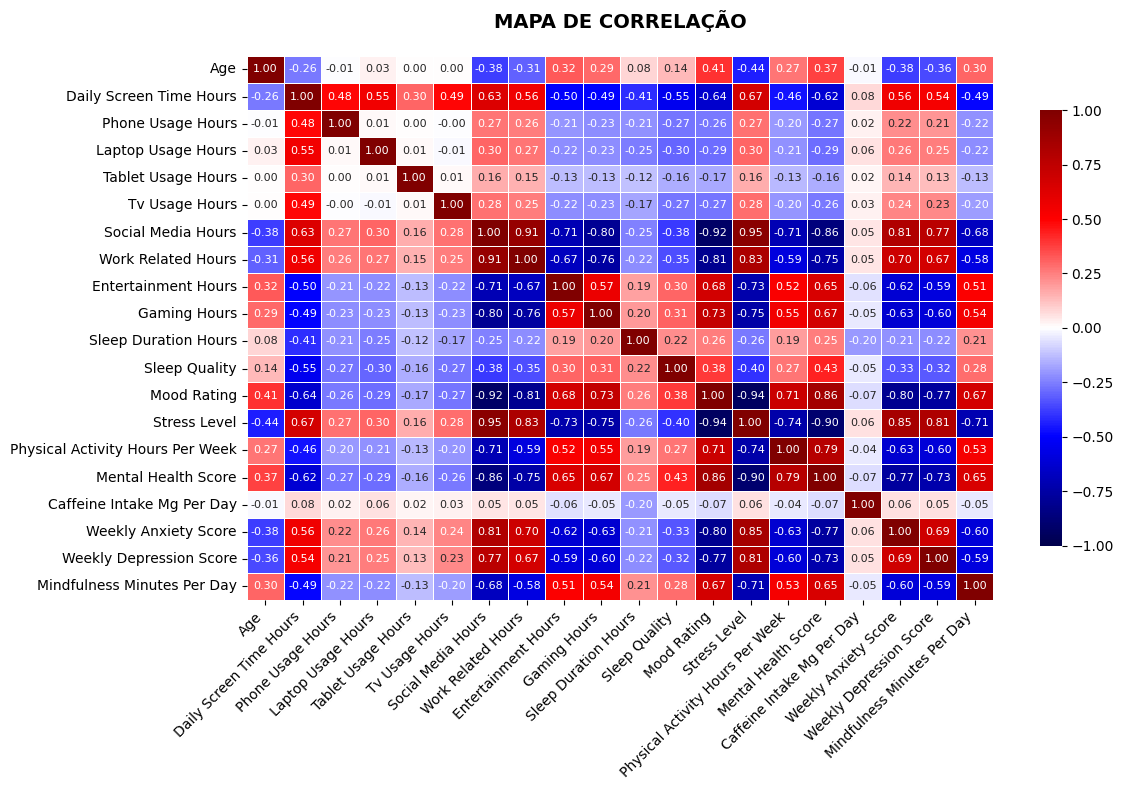

In [16]:
#Selecionamos as colunas numéricas
df_comportamento = df.select_dtypes(include=[np.number]).copy()

plt.figure(figsize=(12, 8))

#Calculando a correlação real
correlacao = df_comportamento.corr()

correlacao.index = [str(c).replace('_', ' ').title() for c in correlacao.index]
correlacao.columns = [str(c).replace('_', ' ').title() for c in correlacao.columns]

sns.heatmap(
    correlacao,
    cmap="seismic",
    vmin=-1,
    vmax=1,
    center=None,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"shrink": .8}
)

plt.title("MAPA DE CORRELAÇÃO", pad=20, fontsize=14, weight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

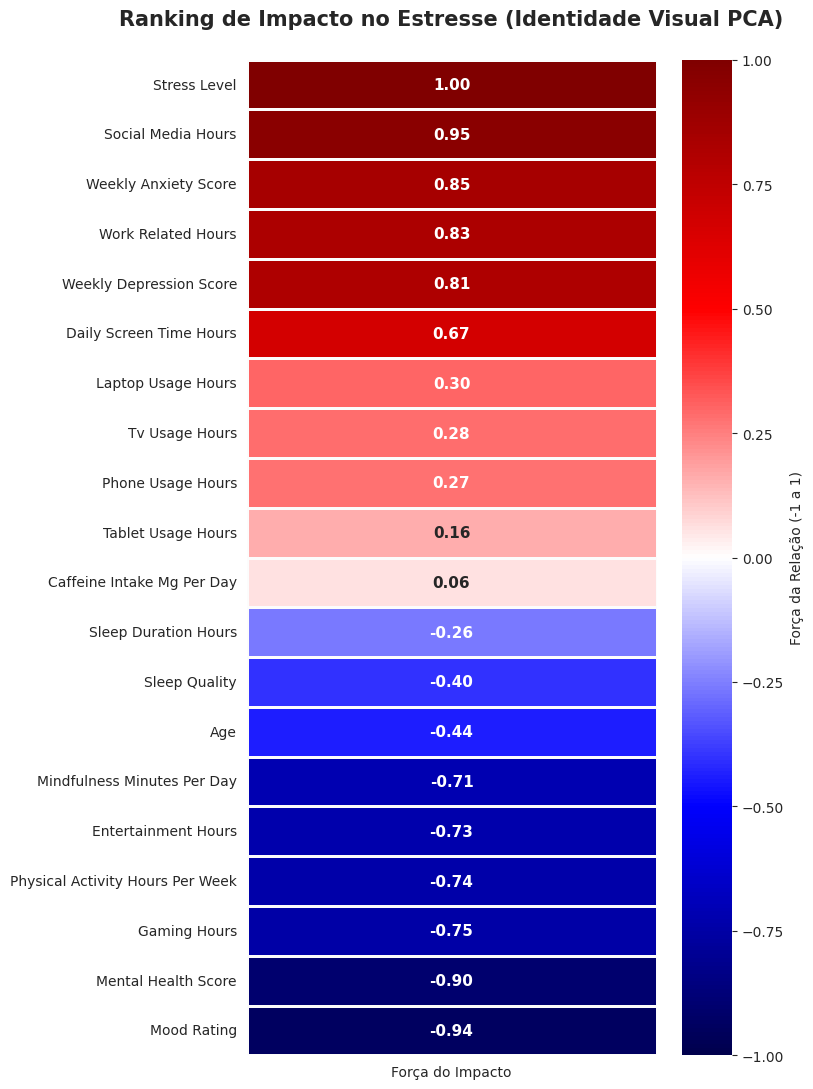

In [17]:
sns.set_style("white")

#Calculando a correlação focada no Alvo
corr_stress_level = (
    df.select_dtypes(include="number")
    .corr()[["stress_level"]]
    .sort_values(by="stress_level", ascending=False)
)

corr_stress_level.index = [str(c).replace('_', ' ').title() for c in corr_stress_level.index]
corr_stress_level.columns = ['Força do Impacto']

plt.figure(figsize=(8, 11))

sns.heatmap(
    corr_stress_level,
    annot=True,
    fmt=".2f",
    cmap="seismic",
    vmin=-1,
    vmax=1,
    linewidths=1,
    linecolor="#fcfcfc",
    cbar_kws={"label": "Força da Relação (-1 a 1)"},
    annot_kws={"weight": "bold", "size": 11}
)

plt.title("Ranking de Impacto no Estresse (Identidade Visual PCA)", fontsize=15, weight="bold", pad=25)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# **Interpretação dos Dados: A Escala de Intensidade (1 a 10)**

Os dados utilizados nesta análise foram coletados em uma escala de **intensidade de 1 a 10**, o que permite uma visão granular do comportamento de cada usuário. No contexto da Mineração de Dados e do PCA, essa numeração funciona da seguinte forma:

> **Magnitude do Atributo:** Cada número representa o **"peso" de um sintoma ou hábito**. Por exemplo, um valor **10** em "Ansiedade" indica um estado **crítico**, enquanto um **1** em "Qualidade do Sono" indica uma **noite extremamente mal dormida**.

>**Vetor de Influência no PCA:** O algoritmo de PCA utiliza esses valores para calcular a **distância entre os perfis**. Quando vários atributos de um usuário estão **próximos de 10** (como Ansiedade e Horas de Tela), o modelo identifica uma **forte correlação positiva e agrupa esses pontos no setor de Alto Estresse** (os pontos vermelhos no gráfico).




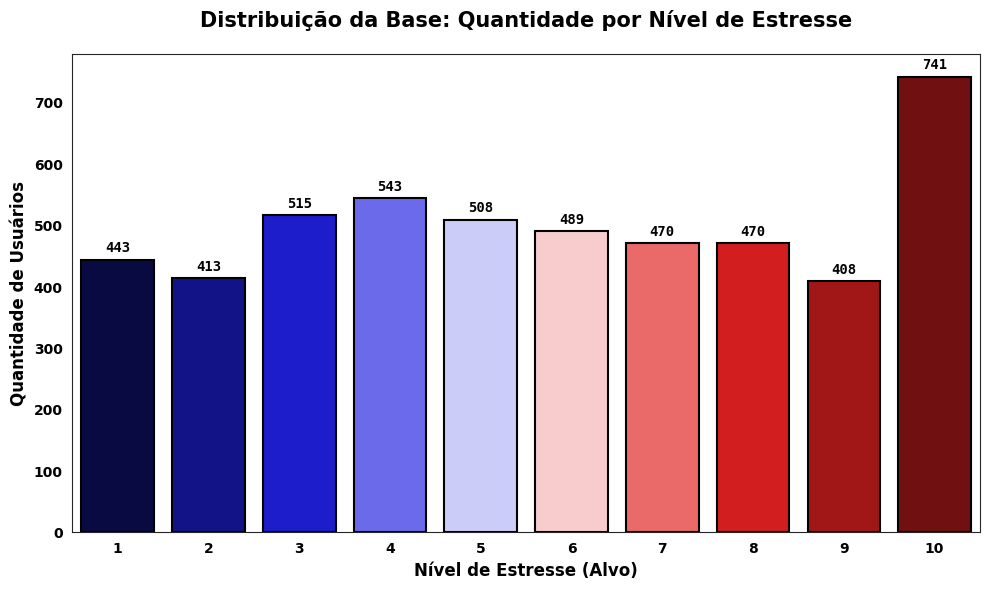

In [18]:
plt.figure(figsize=(10, 6))
sns.set_style("white")

#Criando o gráfico de contagem
ax = sns.countplot(
    x='stress_level',
    data=df,
    hue='stress_level',
    palette='seismic',
    edgecolor='black',
    linewidth=1.5,
    legend=False
)

plt.title("Distribuição da Base: Quantidade por Nível de Estresse", fontsize=15, weight="bold", color="black", pad=20)
plt.xlabel("Nível de Estresse (Alvo)", fontsize=12, weight="bold", color="black")
plt.ylabel("Quantidade de Usuários", fontsize=12, weight="bold", color="black")

plt.xticks(weight="bold", color="black")
plt.yticks(weight="bold", color="black")

#Adicionando os números em cima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                weight="bold", color="black", family="monospace")

plt.tight_layout()
plt.show()

# **Normalização (Escore-z)**

> A etapa de Normalização via Escore-z (StandardScaler) constitui um procedimento estatístico de pré-processamento, cuja finalidade é padronizar a **escala de todos os atributos do dataset**, centralizando a média **em 0 ($\mu = 0$) e definindo o desvio padrão unitário ($\sigma = 1$)**.

A normalização mitiga o viés algorítmico causado por variáveis com ordens de **grandeza superiores** (ex: ingestão de cafeína em miligramas), impedindo que estas dominem a análise de atributos com **escalas reduzidas** (ex: níveis de estresse e humor). Dessa forma, assegura-se que todas as dimensões do conjunto de dados possuam uma contribuição equânime na extração da variância e no cálculo das distâncias euclidianas, resultando em um **modelo matematicamente imparcial e em uma segmentação de perfis fundamentada na estrutura real dos comportamentos, e não na unidade de medida.**

In [19]:
#Inicializamos o escalonador (StandardScaler)
scaler = StandardScaler()

#Aplicando a normalização nos dados
dados_normalizados = scaler.fit_transform(df_limpo)

#Convertendo de volta para DataFrame para podermos conferir o resultado
df_normalizado = pd.DataFrame(dados_normalizados, columns=df_limpo.columns)

print("Normalização concluída com sucesso!")
print("Agora todas as variáveis possuem o mesmo peso matemático para o PCA.")

df_normalizado.head()

Normalização concluída com sucesso!
Agora todas as variáveis possuem o mesmo peso matemático para o PCA.


,age,daily_screen_time_hours,phone_usage_hours,laptop_usage_hours,tablet_usage_hours,tv_usage_hours,social_media_hours,work_related_hours,entertainment_hours,gaming_hours,sleep_duration_hours,sleep_quality,mood_rating,physical_activity_hours_per_week,mental_health_score,caffeine_intake_mg_per_day,weekly_anxiety_score,weekly_depression_score,mindfulness_minutes_per_day
0,0.480668,0.960057,1.016863,0.531089,-0.310363,0.610397,-0.811709,-0.435628,0.966977,0.926829,-0.496634,-0.014163,0.416240,0.760571,1.087009,0.160091,-0.320460,-0.967483,-0.569440
1,1.233629,-0.510969,0.118574,0.043708,-0.500699,-0.681540,-0.396266,0.169008,0.512143,0.057084,-1.048287,-0.014163,0.560755,0.629488,0.476064,-0.361079,-0.320460,0.530831,-0.381746
2,-0.098534,-0.184074,1.802866,-1.515911,-0.310363,-0.035571,0.351531,0.289935,-1.003971,-0.957618,-2.519360,-0.014163,-0.053435,-0.550261,0.170591,1.505622,0.465077,-0.111303,0.118770
3,-0.909416,0.524197,2.813440,-1.515911,-0.881373,-0.143233,1.016240,0.773644,-1.307193,-1.827363,-0.128866,-0.014163,-1.137299,-1.161983,-0.745826,-0.170842,1.643384,1.387011,-0.581953
4,0.712348,0.905575,1.578293,0.433613,0.260647,-0.250894,0.434620,0.169008,-0.700748,0.636914,-0.680519,-0.014163,-0.306336,0.061461,-0.211249,1.000305,-0.713229,0.102742,1.019700


# **Análise Multivariada: O Mapa do Stress (PCA)**

Como os dados possuem muitas variáveis que interagem **entre si** (sono, tecnologia, ansiedade), utilizamos o PCA para simplificar esta complexidade. O objetivo é reduzir todas as colunas a apenas dois eixos **($PC1$ e $PC2$)**, permitindo visualizar padrões que seriam impossíveis de ver em tabelas comuns.

**O que observar no gráfico:**

> **Agrupamentos:** Se pontos da **mesma cor** (mesmo nível de stress) estão próximos, a base de dados é consistente.

> **Separação:** A **distância entre as cores** revela quais perfis de comportamento são opostos (ex: o que diferencia um perfil calmo de um perfil em burnout).





In [20]:
# @title
#CÁLCULO DO PCA (REDUÇÃO DE DIMENSIONALIDADE)

#Definimos o PCA para reduzir tudo para 2 componentes (Visualização 2D)
pca = PCA(n_components=2)

#Aplicamos o PCA nos dados que acabamos de normalizar
componentes_principais = pca.fit_transform(df_normalizado)

#Criamos um DataFrame com os resultados
df_pca = pd.DataFrame(data=componentes_principais, columns=['PC1', 'PC2'])

#Adicionamos a coluna de estresse original para colorir o gráfico depois
df_pca['Stress_Level'] = df['stress_level'].values

print("PCA calculado com sucesso!")
print(f"Variância explicada pelas duas componentes: {pca.explained_variance_ratio_.sum():.2%}")

PCA calculado com sucesso!
Variância explicada pelas duas componentes: 53.23%


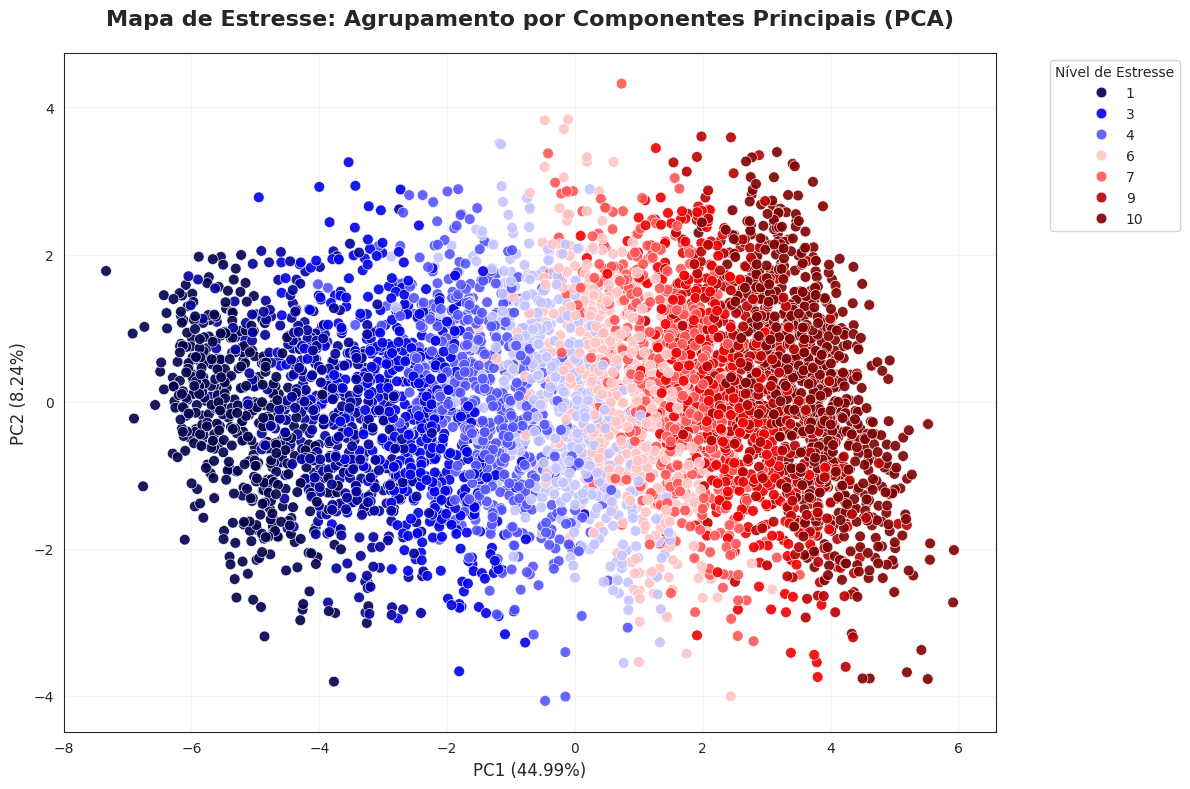

In [21]:
plt.figure(figsize=(12, 8))

scatter = sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Stress_Level',
    palette='seismic',
    data=df_pca,
    alpha=0.9,
    s=60,
    edgecolor='w',
    linewidth=0.5
)

plt.title("Mapa de Estresse: Agrupamento por Componentes Principais (PCA)", fontsize=16, weight='bold', pad=20)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})", fontsize=12)

plt.legend(title="Nível de Estresse", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

# **O que o PCA mostra?**

A Análise de Componentes Principais (PCA) foi aplicada para **reduzir a dimensionalidade do conjunto de dados**, permitindo a visualização da estrutura multivariada em apenas duas dimensões (PC1 e PC2).

# **PC1: O Eixo dos Riscos Mentais (44,99% da Variância)**
O primeiro componente principal é o fator determinante do projeto. Ele atua como um indexador que sintetiza as variáveis de **maior impacto**.

> **Gradiente de Estresse:** A transição das cores (do azul ao vermelho) ao longo do Eixo X confirma que o PC1 **captura a transição entre o perfil saudável e o crítico**.

>**Composição:** Este eixo reflete a forte correlação entre o uso intenso de tecnologias, elevados scores de ansiedade e a degradação da saúde mental.

# **PC2: O Eixo de Estilo de Vida e Comportamento (8,24% da Variância)**
O segundo componente principal captura variações que o **PC1 não explica**. Ele é responsável por **"espalhar" os dados verticalmente**.

>**Diversidade Comportamental:** Este eixo diferencia os indivíduos por **hábitos secundários e características demográficas**, mostrando que pessoas com o **mesmo nível de estresse** (mesma posição no X) podem ter rotinas e perfis de uso** tecnológico distintos** (posições diferentes no Y).






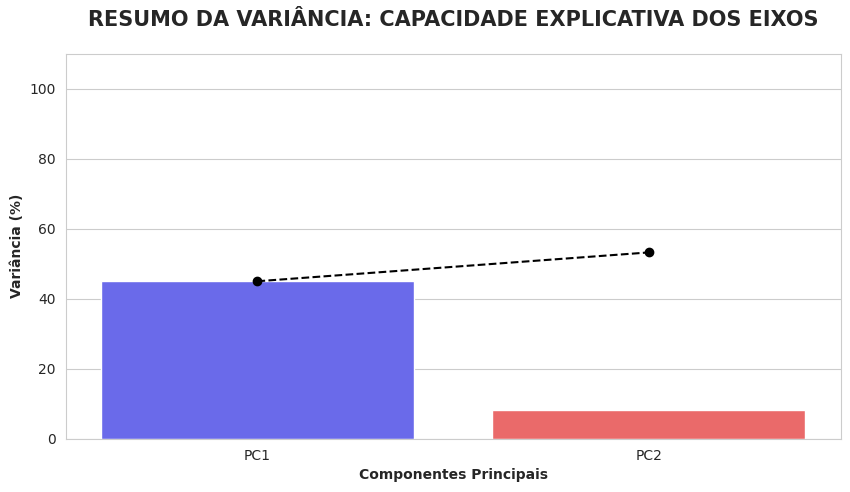

In [22]:
# @title
#Preparação dos dados
variancia_percentual = pca.explained_variance_ratio_ * 100
variancia_acumulada = np.cumsum(pca.explained_variance_ratio_) * 100

df_variancia = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(variancia_percentual))],
    'Variância Individual (%)': variancia_percentual,
    'Variância Acumulada (%)': variancia_acumulada
}).set_index('Componente')

#Gerar o Gráfico
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

ax = sns.barplot(x=df_variancia.index,
                 y=df_variancia['Variância Individual (%)'],
                 palette='seismic',
                 hue=df_variancia.index,
                 legend=False)

plt.plot(range(len(df_variancia)), df_variancia['Variância Acumulada (%)'],
         marker='o', color='black', linestyle='--', label='Acumulada')

plt.title('RESUMO DA VARIÂNCIA: CAPACIDADE EXPLICATIVA DOS EIXOS', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Variância (%)', fontweight='bold')
plt.xlabel('Componentes Principais', fontweight='bold')
plt.ylim(0, 110)
plt.show()

In [23]:
# @title
cm = plt.cm.seismic

styled_variancia = (df_variancia.style
    .background_gradient(cmap=cm, axis=0)
    .format("{:.2f}%")
    .set_properties(**{
        "color": "white",
        "border": "2px solid black",
        "padding": "15px 30px",
        "font-size": "13px",
        "text-align": "center",
        "font-weight": "bold",
        "min-width": "160px"
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#f8f9fa'),
                ('color', 'black'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '12px'),
                ('border', '2px solid black'),
                ('text-transform', 'uppercase')
            ]
        },
        {
            'selector': 'caption',
            'props': [
                ('color', 'black'),
                ('font-size', '16px'),
                ('font-weight', 'bold'),
                ('padding-bottom', '25px')
            ]
        }
    ]))

styled_variancia

,Variância Individual (%),Variância Acumulada (%)
Componente,,
PC1,44.99%,44.99%
PC2,8.24%,53.23%


# **PC1: O Eixo dos Riscos Mentais**

A Primeira Componente Principal (PC1) **concentra a maior parte da variância dos dados**. No contexto deste projeto, ela funciona como um Índice Geral de Risco.

Como os **fatores de risco (telas/ansiedade) e de proteção (sono/saúde mental) têm pesos opostos nessa componente**, o PC1 cria uma linha de separação clara: indivíduos posicionados em valores altos de PC1 são aqueles que acumulam simultaneamente alta exposição digital e baixa recuperação de sono. Portanto, o PC1 é o eixo que define a **intensidade do estresse**.

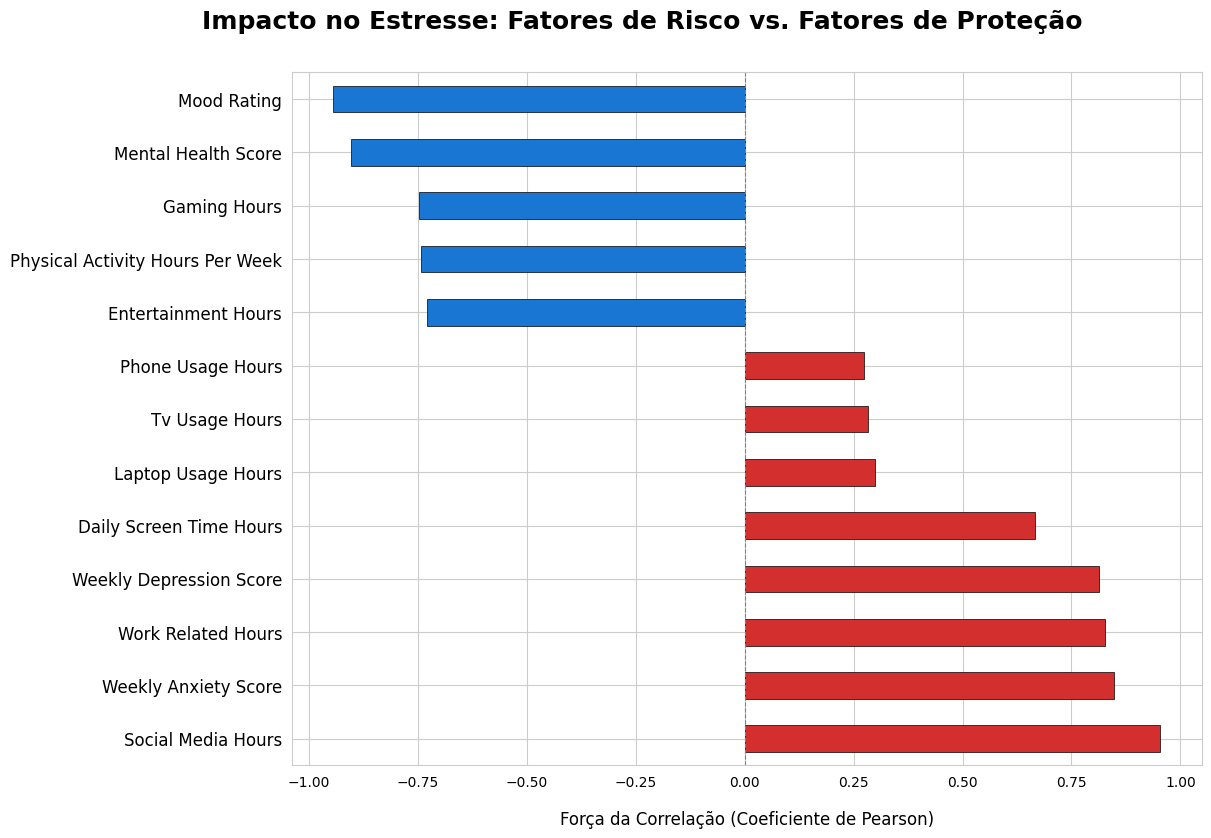

In [24]:
plt.figure(figsize=(14, 9))
sns.set_style("whitegrid")

#Calcula a correlação focada no Alvo 'stress_level'
correlacoes = df.select_dtypes(include=[np.number]).corr()['stress_level'].sort_values(ascending=False)
correlacoes = correlacoes.drop(['stress_level', 'Unnamed: 0', 'User_Id'], errors='ignore')

#Seleciona os impactos (8 que aumentam e 5 que reduzem)
top_corr = pd.concat([correlacoes.head(8), correlacoes.tail(5)])

colors_aesthetic = ['#d32f2f' if x > 0 else '#1976d2' for x in top_corr.values]

ax = top_corr.plot(kind='barh', color=colors_aesthetic, edgecolor='black', linewidth=0.5)

plt.suptitle('Impacto no Estresse: Fatores de Risco vs. Fatores de Proteção',
             fontsize=18, fontweight='bold', color='black', x=0.5, y=0.95)

plt.xlabel('Força da Correlação (Coeficiente de Pearson)', fontsize=12, color='black', labelpad=15)
plt.ylabel('')

plt.gca().tick_params(axis='y', labelcolor='black', labelsize=12)
plt.gca().tick_params(axis='x', labelcolor='black')

plt.axvline(0, color='grey', lw=0.8, ls='--')

plt.gca().set_yticklabels([str(label.get_text()).replace('_', ' ').title() for label in plt.gca().get_yticklabels()])

plt.subplots_adjust(left=0.25, top=0.88)

plt.show()

# **PC2: O Diferencial de Comportamento**

Enquanto o **PC1 mostra a força do estresse**, a S**egunda Componente Principal (PC2) revela padrões secundários que a média não explica**.

O PC2 geralmente captura as **"exceções" ou nuances específicas**, como pessoas que possuem alto tempo de tela, mas conseguem manter uma atividade física ou sono regular. Ele separa os perfis **não pela gravidade do estresse**, mas **pela origem do problema** (ex: se o impacto é predominantemente comportamental/físico ou puramente emocional/psicológico). É o eixo que traz o "refino" para o agrupamento dos dados no mapa final.

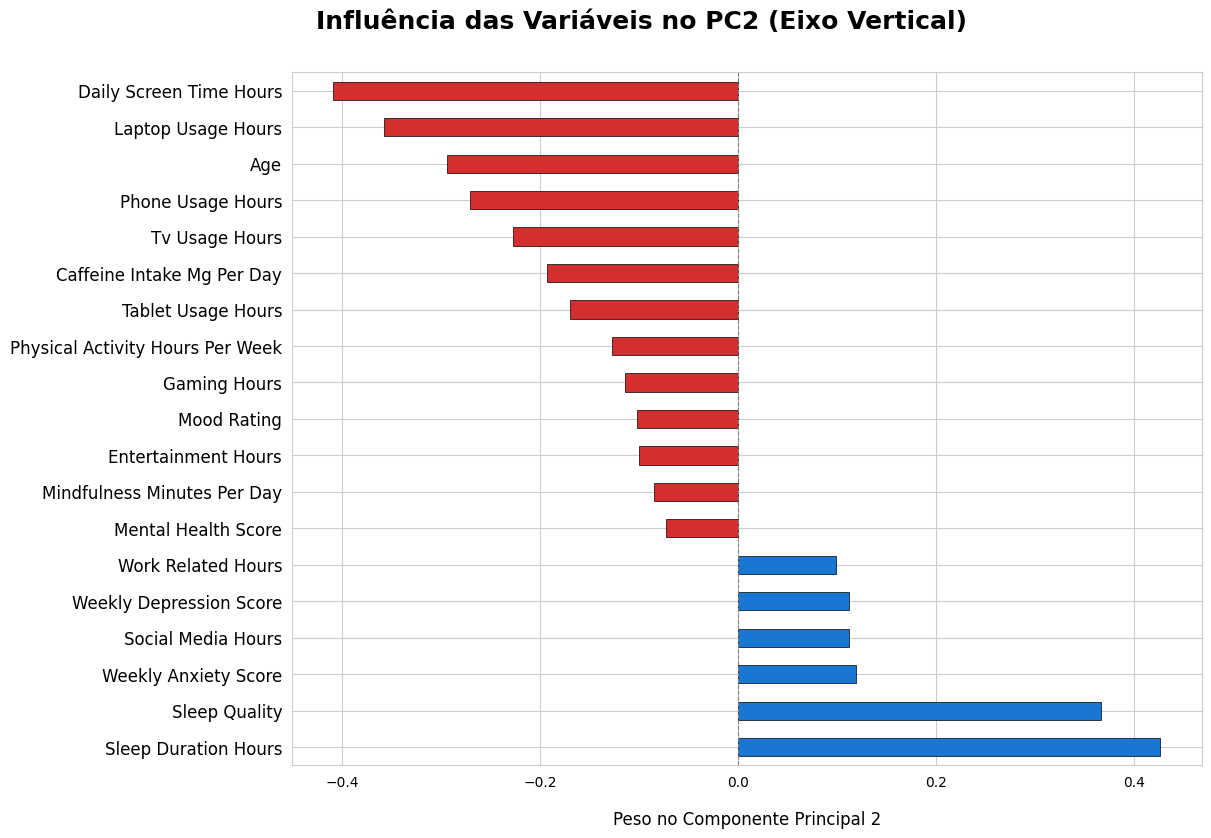

In [25]:
plt.figure(figsize=(14, 9))
sns.set_style("whitegrid")

#Extração dos Pesos das componentes
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df_normalizado.columns
)

#Ordenando o PC2 para ver a influência no Eixo Y
pc2_data = loadings['PC2'].sort_values(ascending=False)

colors_pc2 = ['#1976d2' if x > 0 else '#d32f2f' for x in pc2_data.values]
ax_pc2 = pc2_data.plot(kind='barh', color=colors_pc2, edgecolor='black', linewidth=0.5)

plt.suptitle('Influência das Variáveis no PC2 (Eixo Vertical)',
             fontsize=18, fontweight='bold', color='black', x=0.5, y=0.95)

plt.xlabel('Peso no Componente Principal 2', fontsize=12, color='black', labelpad=15)
plt.ylabel('')

plt.gca().tick_params(axis='y', labelcolor='black', labelsize=12)
plt.gca().tick_params(axis='x', labelcolor='black')

plt.axvline(0, color='grey', lw=0.8, ls='--')

plt.gca().set_yticklabels([str(label.get_text()).replace('_', ' ').title() for label in plt.gca().get_yticklabels()])

plt.subplots_adjust(left=0.25, top=0.88)

plt.show()

# **Análise de Correlação: Principais Fatores de Risco e Proteção**

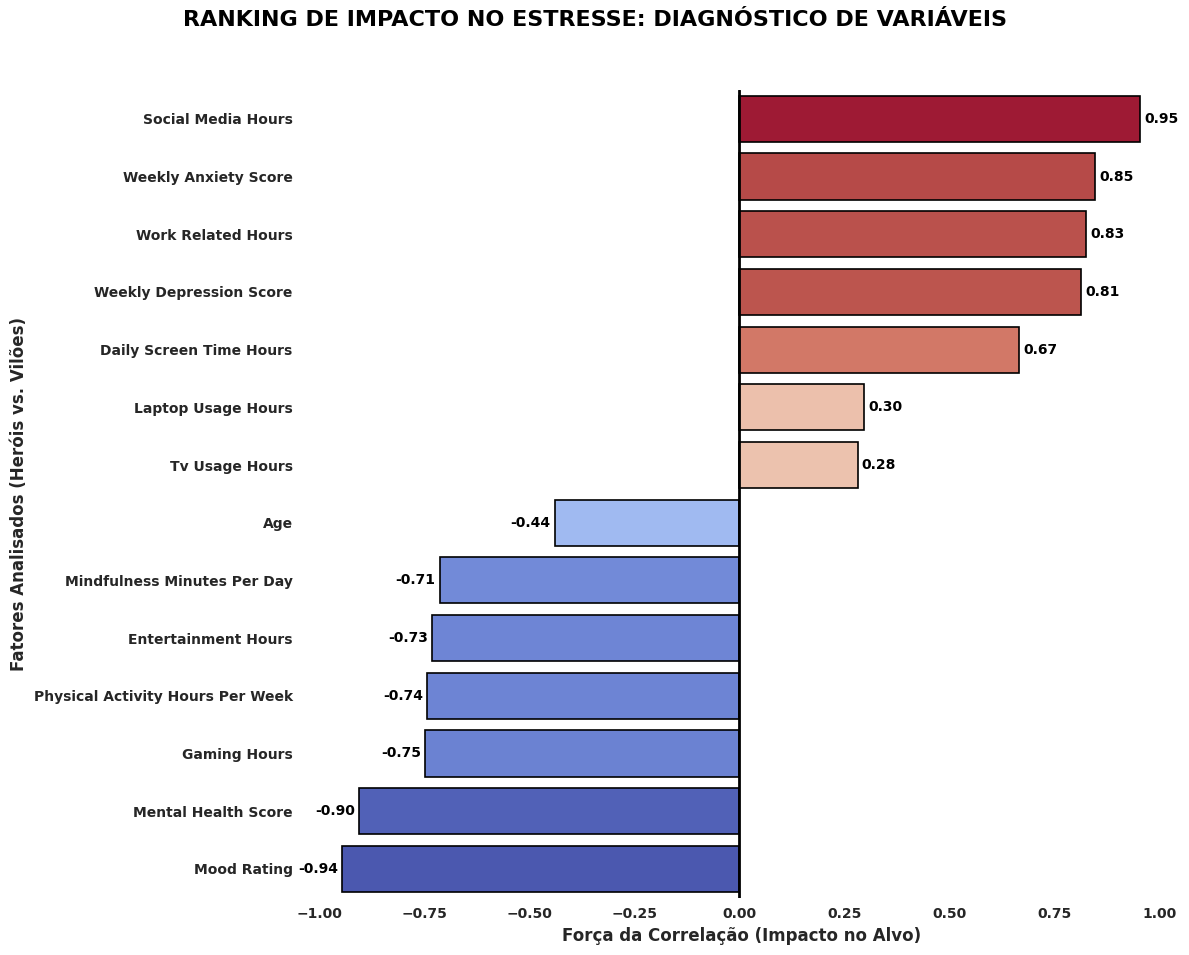

In [26]:
# @title
plt.figure(figsize=(12, 10))
sns.set_style("white")

#Processamento das correlações (Focando no Stress Level)
df_numerico = df.select_dtypes(include=[np.number])
correlacoes = df_numerico.corr()['stress_level'].sort_values(ascending=False)

correlacoes = correlacoes.drop(labels=['stress_level', 'user_id', 'Unnamed: 0'], errors='ignore')

top_riscos = correlacoes.head(7)# Os 7 que MAIS aumentam o estresse
top_protecoes = correlacoes.tail(7)# Os 7 que MAIS reduzem o estresse
dados_plot = pd.concat([top_riscos, top_protecoes])

norm = plt.Normalize(dados_plot.values.min(), dados_plot.values.max())
paleta_gradiente = list(plt.cm.coolwarm(norm(dados_plot.values)))

ax = sns.barplot(
    x=dados_plot.values,
    y=dados_plot.index,
    palette=paleta_gradiente,
    hue=dados_plot.index,
    legend=False,
    edgecolor='black',
    linewidth=1.2
)

plt.suptitle("RANKING DE IMPACTO NO ESTRESSE: DIAGNÓSTICO DE VARIÁVEIS",
             fontsize=16, weight="bold", color="black", y=0.98)

plt.xlabel("Força da Correlação (Impacto no Alvo)", fontsize=12, weight="bold")
plt.ylabel("Fatores Analisados (Heróis vs. Vilões)", fontsize=12, weight="bold")

ax.set_yticks(range(len(dados_plot.index)))
ax.set_yticklabels([str(label).replace('_', ' ').title() for label in dados_plot.index], weight="bold")

plt.xticks(weight="bold")

plt.axvline(0, color='black', linewidth=2)

for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + (0.01 if width > 0 else -0.01),
        p.get_y() + p.get_height() / 2,
        f"{width:.2f}",
        ha='left' if width > 0 else 'right',
        va='center', weight='bold', color='black', fontsize=10
    )

sns.despine(left=True, bottom=True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# **Distribuição de Frequências**

A Distribuição de Frequências é um método estatístico fundamental da **Análise Descritiva** que visa **organizar e resumir um conjunto de dados**, permitindo a compreensão da dispersão e da concentração de uma variável específica dentro da amostra. No contexto deste projeto, esta técnica foi aplicada à variável alvo **(Nível de Estresse)** para diagnosticar o perfil inicial da população estudada.

In [27]:
#fi = Frequência Absoluta | fr = Frequência Relativa | Fi = Frequência Acumulada
fi_stress = df['stress_level'].value_counts().sort_index()
fr_stress = df['stress_level'].value_counts(normalize=True).sort_index() * 100
Fi_stress = fi_stress.cumsum()

tabela_stress = pd.DataFrame({
    'Frequência Absoluta (fi)': fi_stress,
    'Frequência Relativa (%) (fr)': fr_stress,
    'Frequência Acumulada (Fi)': Fi_stress
})

print("TABELA: DISTRIBUIÇÃO DE FREQUÊNCIA - NÍVEL DE ESTRESSE")
tabela_stress

TABELA: DISTRIBUIÇÃO DE FREQUÊNCIA - NÍVEL DE ESTRESSE


,Frequência Absoluta (fi),Frequência Relativa (%) (fr),Frequência Acumulada (Fi)
stress_level,,,
1,443,8.86,443
2,413,8.26,856
3,515,10.30,1371
4,543,10.86,1914
5,508,10.16,2422
6,489,9.78,2911
7,470,9.40,3381
8,470,9.40,3851
9,408,8.16,4259


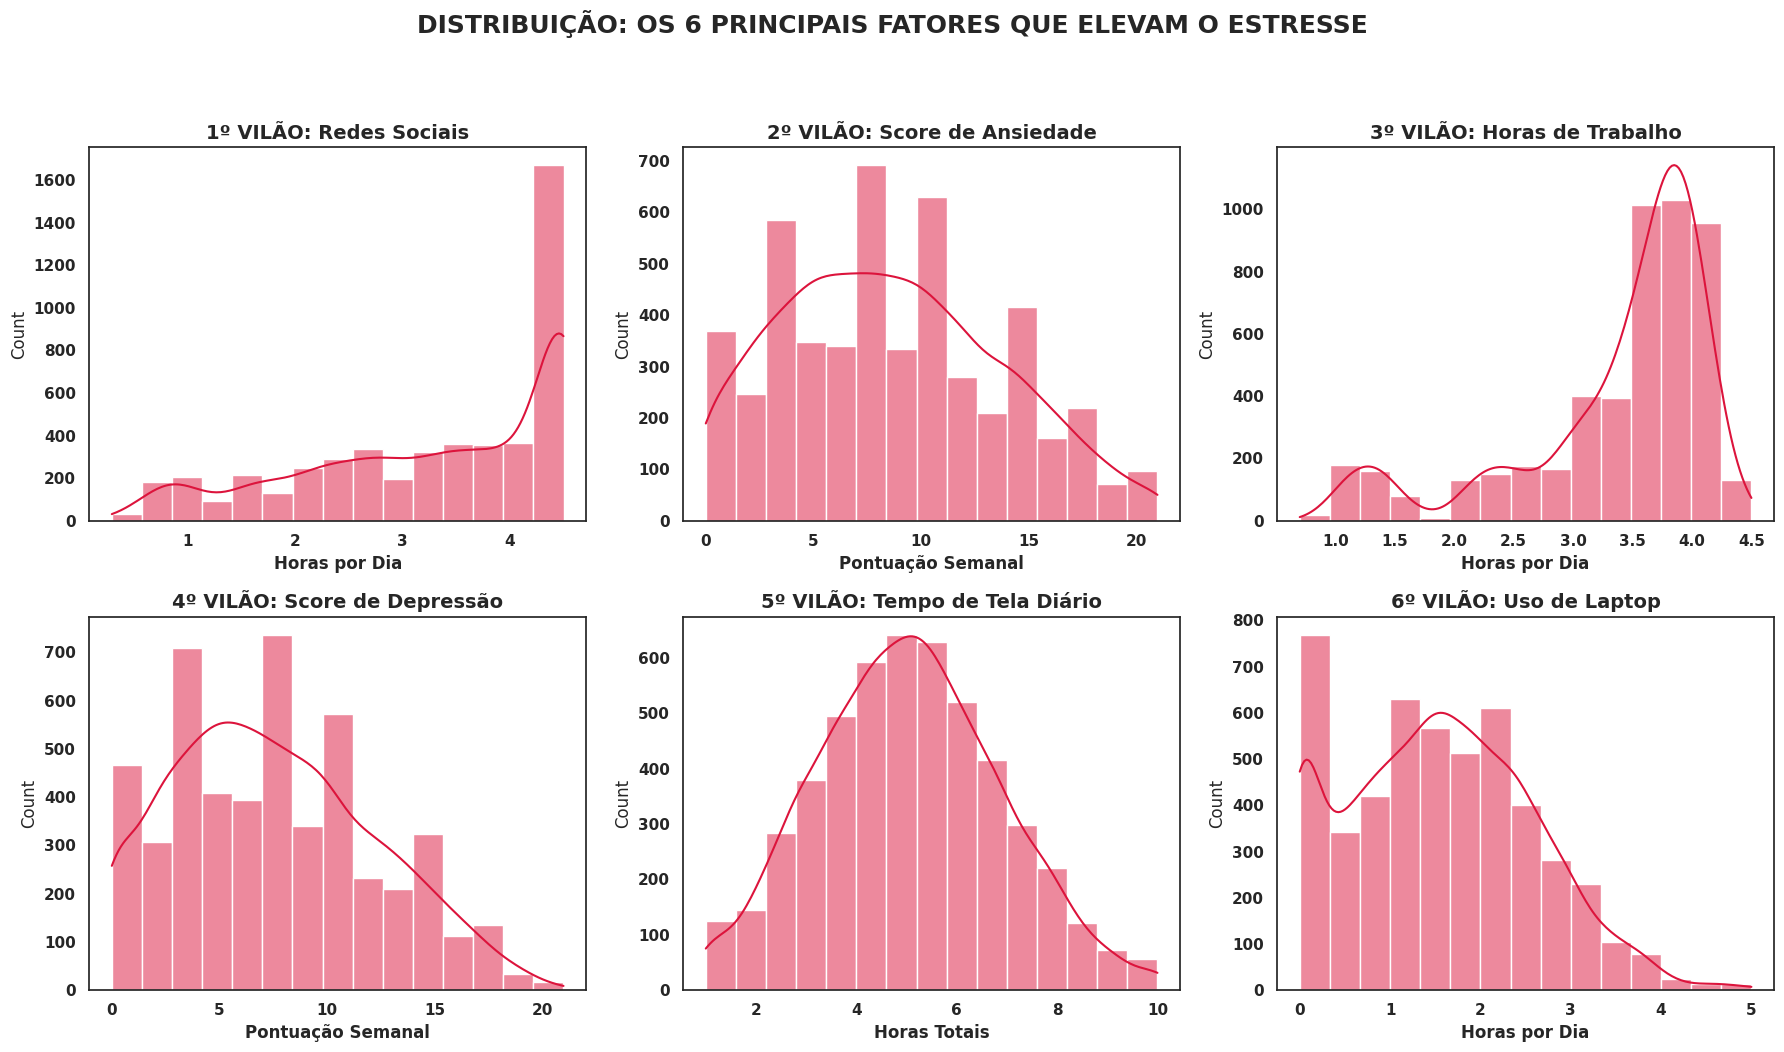

In [28]:
# @title
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DISTRIBUIÇÃO: OS 6 PRINCIPAIS FATORES QUE ELEVAM O ESTRESSE',
             fontsize=18, fontweight='bold', y=1.05)

cor_vilao = '#DC143C'

#VILÃO 1: REDES SOCIAIS
sns.histplot(df['social_media_hours'], bins=15, kde=True, color=cor_vilao, ax=axes[0, 0])
axes[0, 0].set_title('1º VILÃO: Redes Sociais', fontweight='bold', fontsize=14)
axes[0, 0].set_xlabel('Horas por Dia', fontweight='bold')

#VILÃO 2: SCORE DE ANSIEDADE
sns.histplot(df['weekly_anxiety_score'], bins=15, kde=True, color=cor_vilao, ax=axes[0, 1])
axes[0, 1].set_title('2º VILÃO: Score de Ansiedade', fontweight='bold', fontsize=14)
axes[0, 1].set_xlabel('Pontuação Semanal', fontweight='bold')

#VILÃO 3: HORAS DE TRABALHO
sns.histplot(df['work_related_hours'], bins=15, kde=True, color=cor_vilao, ax=axes[0, 2])
axes[0, 2].set_title('3º VILÃO: Horas de Trabalho', fontweight='bold', fontsize=14)
axes[0, 2].set_xlabel('Horas por Dia', fontweight='bold')

#VILÃO 4: SCORE DE DEPRESSÃO
sns.histplot(df['weekly_depression_score'], bins=15, kde=True, color=cor_vilao, ax=axes[1, 0])
axes[1, 0].set_title('4º VILÃO: Score de Depressão', fontweight='bold', fontsize=14)
axes[1, 0].set_xlabel('Pontuação Semanal', fontweight='bold')

#VILÃO 5: TEMPO DE TELA DIÁRIO
sns.histplot(df['daily_screen_time_hours'], bins=15, kde=True, color=cor_vilao, ax=axes[1, 1])
axes[1, 1].set_title('5º VILÃO: Tempo de Tela Diário', fontweight='bold', fontsize=14)
axes[1, 1].set_xlabel('Horas Totais', fontweight='bold')

#VILÃO 6: USO DE LAPTOP
sns.histplot(df['laptop_usage_hours'], bins=15, kde=True, color=cor_vilao, ax=axes[1, 2])
axes[1, 2].set_title('6º VILÃO: Uso de Laptop', fontweight='bold', fontsize=14)
axes[1, 2].set_xlabel('Horas por Dia', fontweight='bold')

for ax in axes.flat:
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontweight('bold')

plt.tight_layout()
plt.show()

# **Análise dos Preditores de Risco (Os "Vilões" do Estresse)**


A seleção dessas seis variáveis fundamenta-se na Matriz de Correlação, onde apresentaram os **maiores coeficientes de proporcionalidade direta em relação ao nível de estresse**. Esta análise univariada permite observar como cada fator se distribui individualmente na amostra.

**Sobrecarga Tecnológica:** Variáveis como Tempo de Tela Diário, Uso de Laptop e Horas em Redes Sociais apresentam distribuições com **picos elevados**, indicando que a exposição digital prolongada é um comportamento prevalente e um **dos principais agentes estressores da base de dados**.

**Impacto Psicossomático:** Os scores de Ansiedade e Depressão atuam como indicadores da saúde mental dos usuários. A morfologia das curvas desses histogramas revela se a amostra possui uma tendência à **estabilidade ou se há uma concentração crítica de indivíduos em zonas de vulnerabilidade**.

**Demanda Laboral:** As Horas de Trabalho complementam o perfil de risco, permitindo diferenciar se o estresse é derivado puramente do estilo de vida **digital** ou se há uma componente **profissional** significativa pressionando os índices de **esgotamento**.

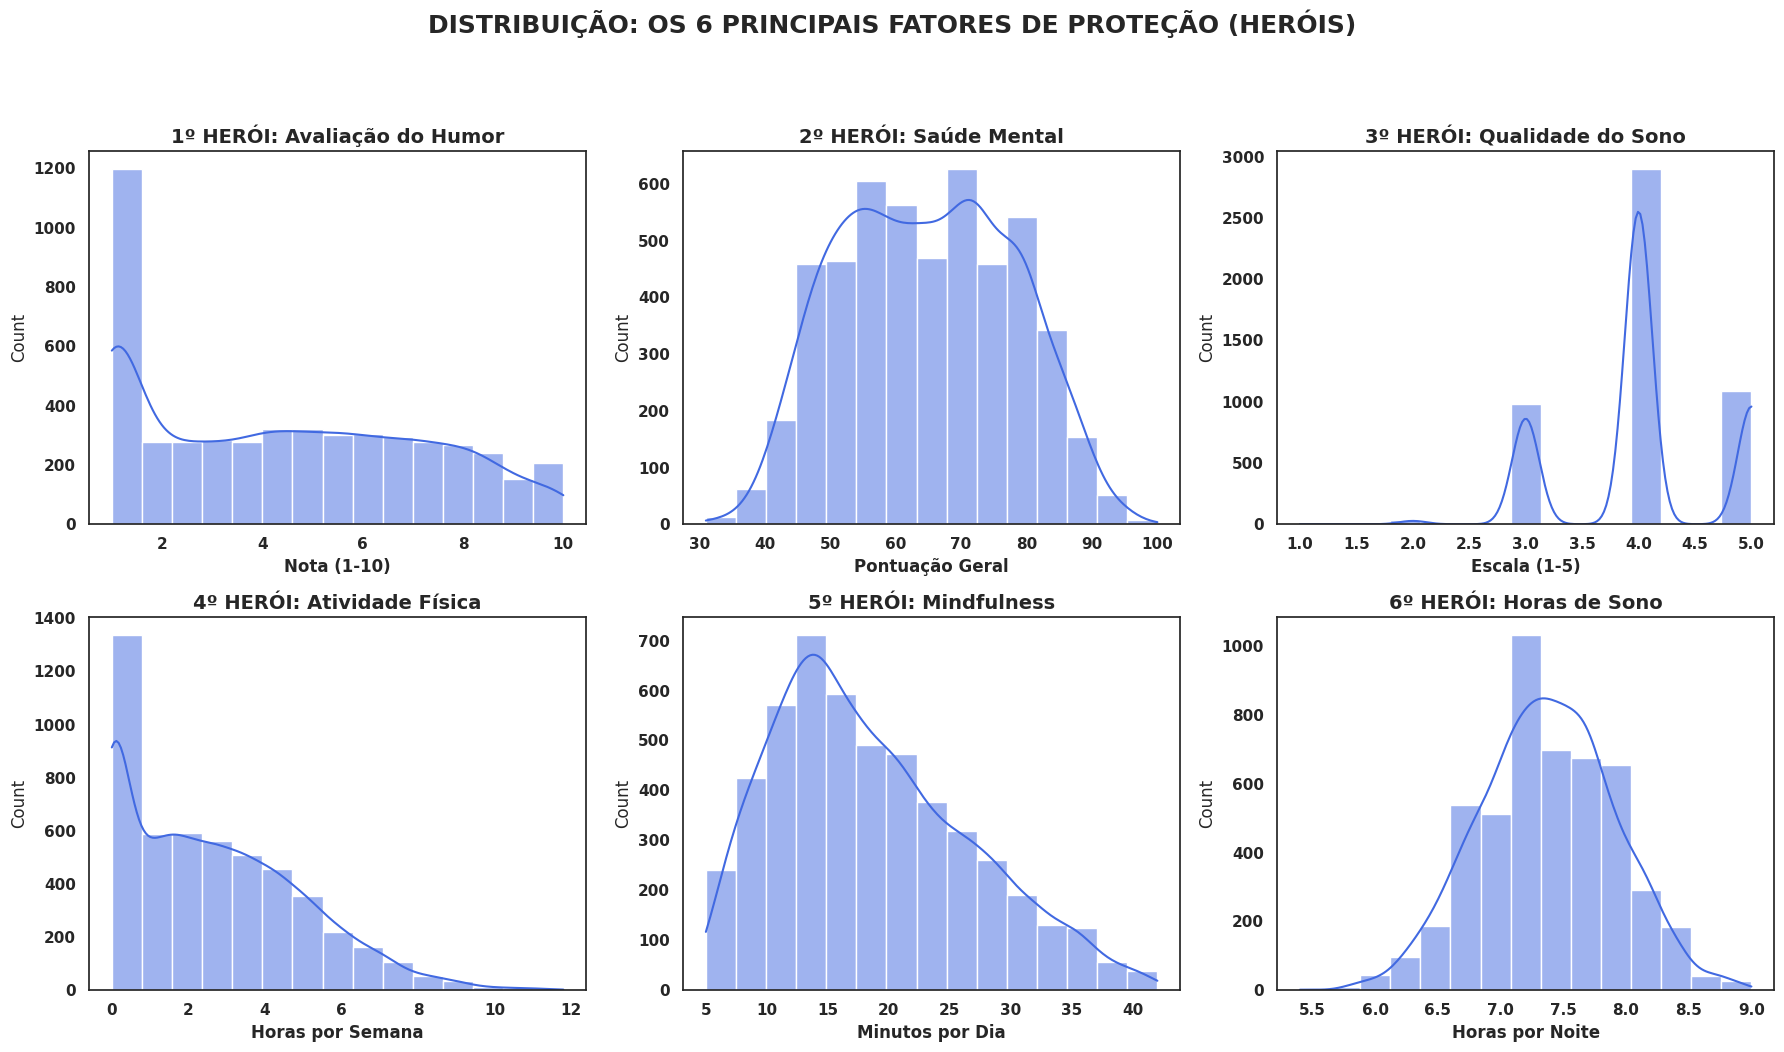

In [29]:
# @title
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DISTRIBUIÇÃO: OS 6 PRINCIPAIS FATORES DE PROTEÇÃO (HERÓIS)',
             fontsize=18, fontweight='bold', y=1.05)

cor_heroi = '#4169E1'

#HERÓI 1: AVALIAÇÃO DO HUMOR
sns.histplot(df['mood_rating'], bins=15, kde=True, color=cor_heroi, ax=axes[0, 0])
axes[0, 0].set_title('1º HERÓI: Avaliação do Humor', fontweight='bold', fontsize=14)
axes[0, 0].set_xlabel('Nota (1-10)', fontweight='bold')

#HERÓI 2: SAÚDE MENTAL
sns.histplot(df['mental_health_score'], bins=15, kde=True, color=cor_heroi, ax=axes[0, 1])
axes[0, 1].set_title('2º HERÓI: Saúde Mental', fontweight='bold', fontsize=14)
axes[0, 1].set_xlabel('Pontuação Geral', fontweight='bold')

#HERÓI 3: QUALIDADE DO SONO
sns.histplot(df['sleep_quality'], bins=15, kde=True, color=cor_heroi, ax=axes[0, 2])
axes[0, 2].set_title('3º HERÓI: Qualidade do Sono', fontweight='bold', fontsize=14)
axes[0, 2].set_xlabel('Escala (1-5)', fontweight='bold')

#HERÓI 4: ATIVIDADE FÍSICA
sns.histplot(df['physical_activity_hours_per_week'], bins=15, kde=True, color=cor_heroi, ax=axes[1, 0])
axes[1, 0].set_title('4º HERÓI: Atividade Física', fontweight='bold', fontsize=14)
axes[1, 0].set_xlabel('Horas por Semana', fontweight='bold')

#HERÓI 5: MINDFULNESS (MEDITAÇÃO)
sns.histplot(df['mindfulness_minutes_per_day'], bins=15, kde=True, color=cor_heroi, ax=axes[1, 1])
axes[1, 1].set_title('5º HERÓI: Mindfulness', fontweight='bold', fontsize=14)
axes[1, 1].set_xlabel('Minutos por Dia', fontweight='bold')

#HERÓI 6: DURAÇÃO DO SONO
sns.histplot(df['sleep_duration_hours'], bins=15, kde=True, color=cor_heroi, ax=axes[1, 2])
axes[1, 2].set_title('6º HERÓI: Horas de Sono', fontweight='bold', fontsize=14)
axes[1, 2].set_xlabel('Horas por Noite', fontweight='bold')

for ax in axes.flat:
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontweight('bold')

plt.tight_layout()
plt.show()

# **Análise dos Fatores de Proteção (Mecanismos de Resiliência)**

Este painel de histogramas apresenta a distribuição das **seis variáveis** que exercem maior influência positiva na saúde mental da amostra. Estes indicadores são classificados tecnicamente como **Fatores de Proteção**, pois sua presença estatística está associada à redução dos níveis de estresse e ao aumento do bem-estar subjetivo.



> **Interpretação das Variáveis de Proteção:**
**Preditores Biológicos (Sono):** A análise da Duração e Qualidade do Sono permite identificar se a amostra possui **hábitos reparadores**. Curvas deslocadas para a direita nestes gráficos indicam uma população com **maior capacidade de recuperação cognitiva e emocional**.

> **Preditores Comportamentais (Atividade Física e Mindfulness):** Estas variáveis representam hábitos ativos de **mitigação do estresse**. A dispersão observada revela o grau de engajamento dos usuários em práticas que comprovadamente **reduzem a carga de cortisol e aumentam a resiliência mental**.

> **Autoavaliação (Humor e Saúde Mental):** Estes scores refletem a percepção interna do **usuário**. Através da curva de KDE, podemos observar se existe uma concentração de indivíduos em níveis satisfatórios (notas altas), o que fundamentará a criação do "Perfil Resiliente" no modelo de agrupamento.

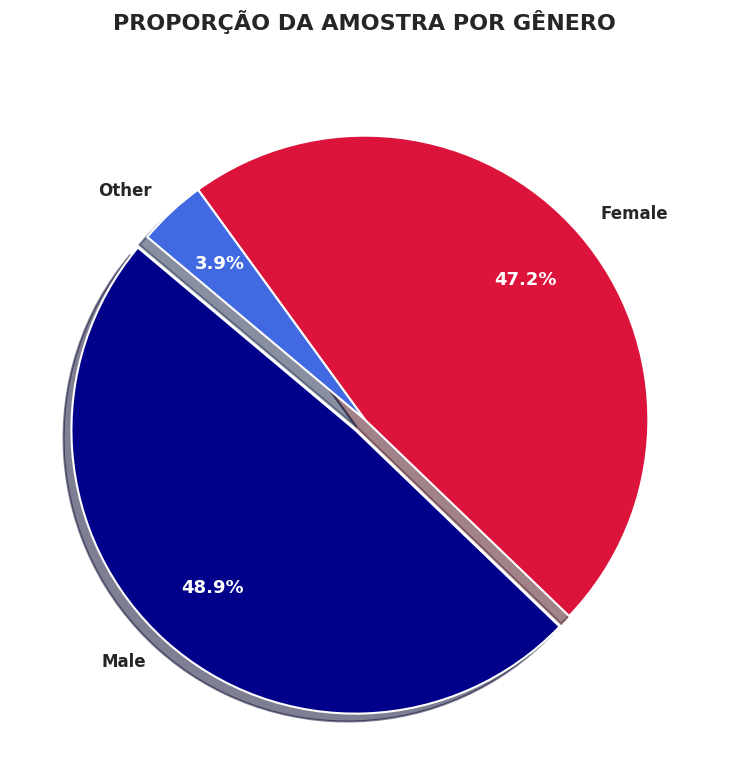

In [30]:
# @title
sns.set_theme(style="white")
plt.figure(figsize=(10, 8))

cores_genero = ['#00008B', '#DC143C', '#4169E1']

#Contagem dos dados
contagem_genero = df['gender'].value_counts()

patches, texts, autotexts = plt.pie(
    contagem_genero,
    labels=contagem_genero.index,
    autopct='%1.1f%%',
    colors=cores_genero,
    explode=[0.05 if i == 0 else 0 for i in range(len(contagem_genero))],
    shadow=True,
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontweight': 'bold', 'fontsize': 12}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
    autotext.set_fontsize(13)

plt.title('PROPORÇÃO DA AMOSTRA POR GÊNERO', fontsize=16, fontweight='bold', pad=25)

plt.tight_layout()
plt.show()

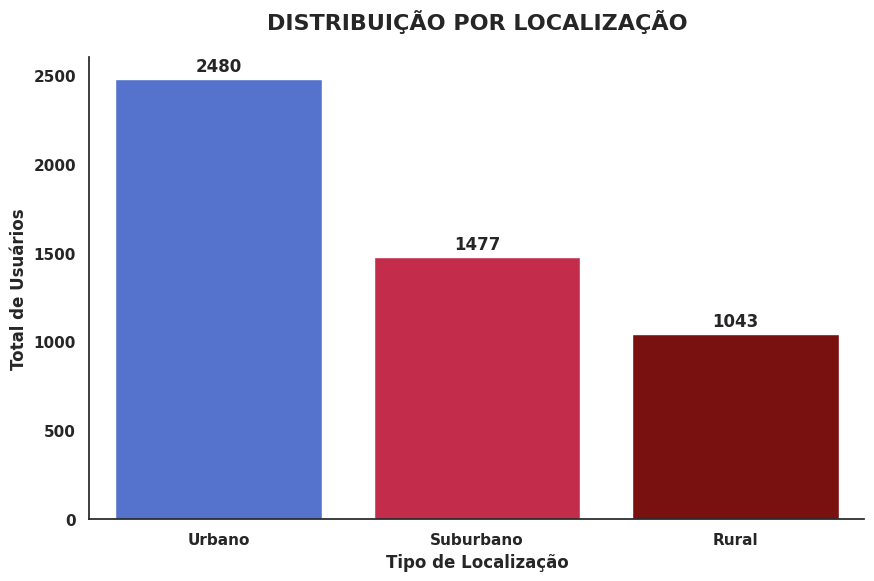

In [31]:
# @title
vermelho_escuro = '#8B0000'
azul_royal = '#4169E1'
vermelho_carmesim = '#DC143C'

mapeamento_local = {
    'Urban': 'Urbano',
    'Rural': 'Rural',
    'Suburban': 'Suburbano'
}

df_plot = df.copy()
df_plot['location_type'] = df_plot['location_type'].map(mapeamento_local)

plt.figure(figsize=(10, 6))
ordem_local = df_plot['location_type'].value_counts().index

#Criando o gráfico
ax = sns.countplot(data=df_plot, x='location_type', hue='location_type', order=ordem_local,
                   palette=[vermelho_escuro, azul_royal, vermelho_carmesim])

if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.title('DISTRIBUIÇÃO POR LOCALIZAÇÃO', fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Tipo de Localização', fontweight='bold', fontsize=12)
plt.ylabel('Total de Usuários', fontweight='bold', fontsize=12)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontweight='bold')

sns.despine()
plt.show()

# **Análise de Densidade: Impacto dos Hábitos no Nível de Estresse**

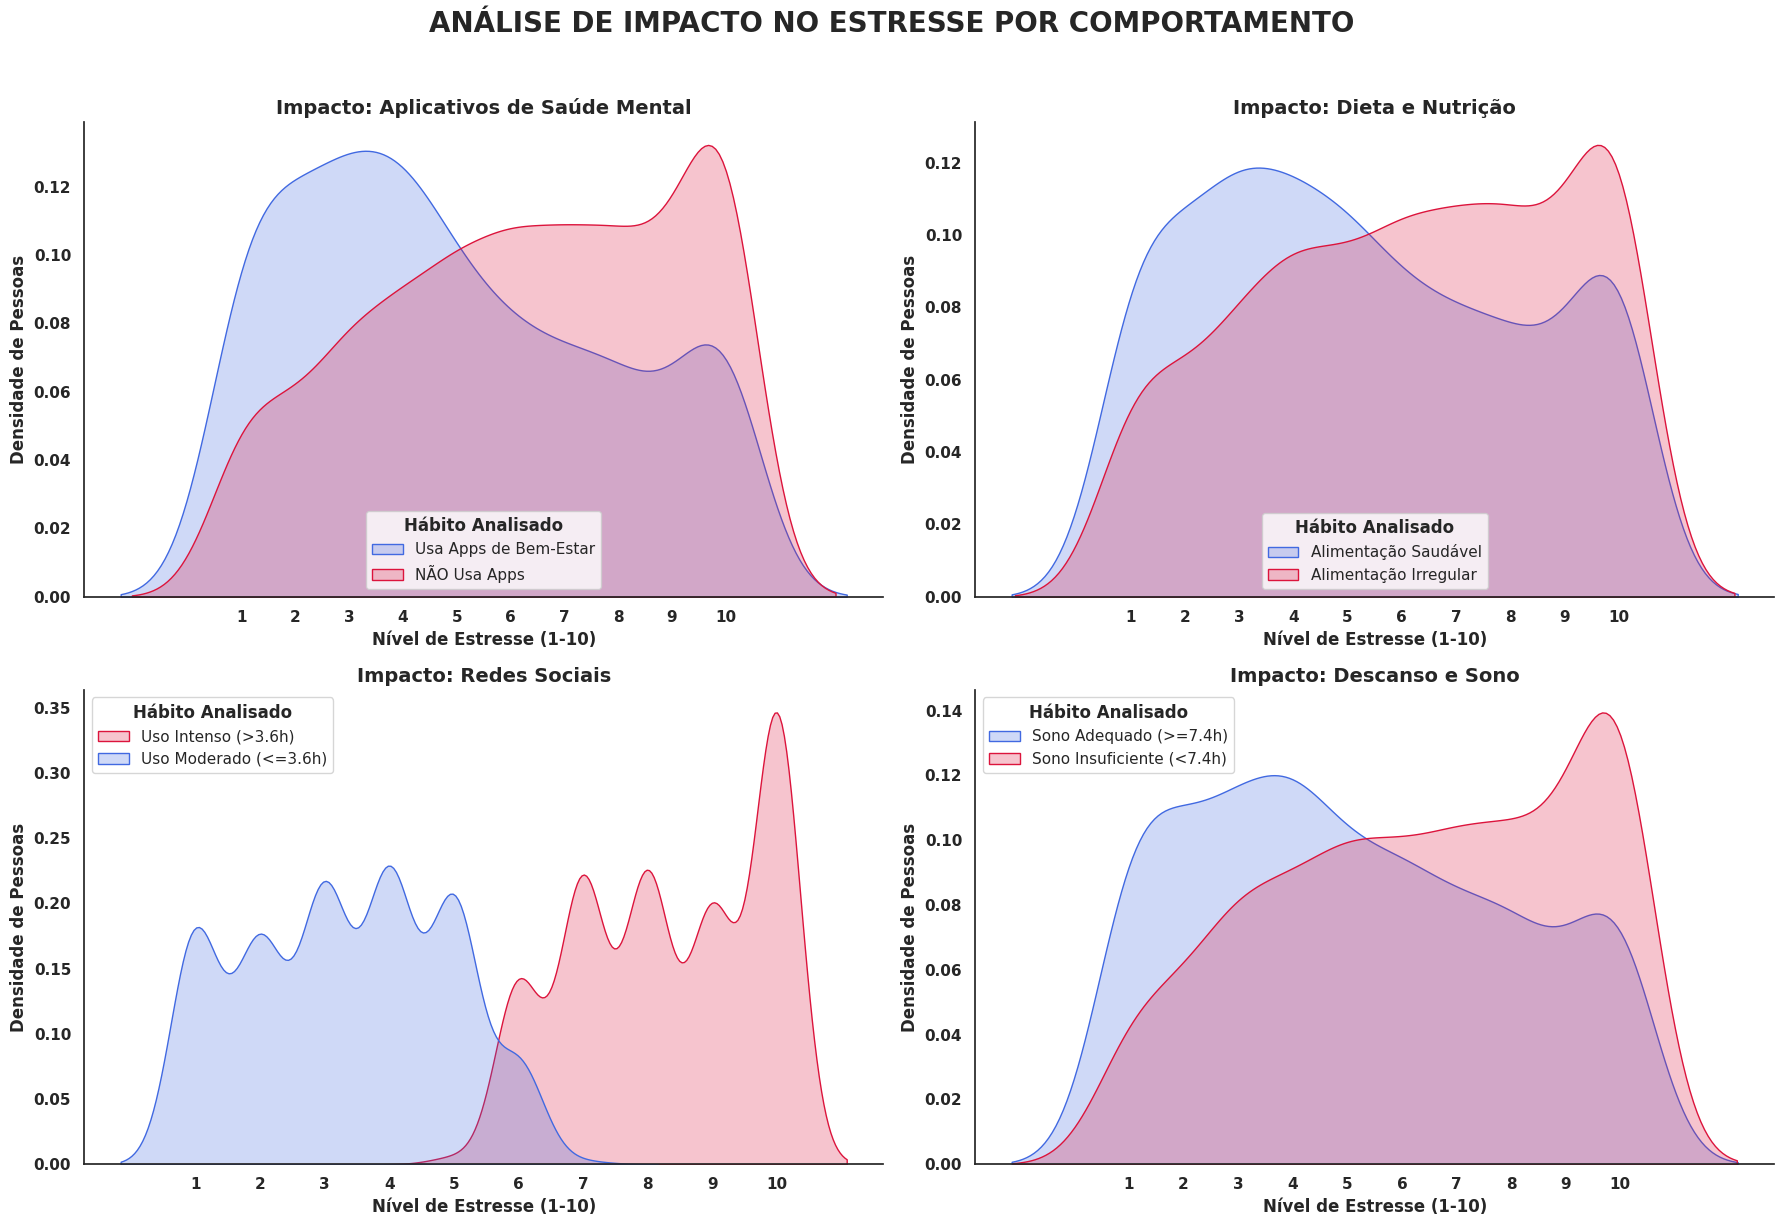

In [32]:
# @title
#Configuração do Painel (2 linhas e 2 colunas)
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('ANÁLISE DE IMPACTO NO ESTRESSE POR COMPORTAMENTO',
             fontsize=20, fontweight='bold', y=1.02)

cor_heroi = '#4169E1'
cor_vilao = '#DC143C'

#Medianas para divisão de grupos numéricos
mediana_social = df['social_media_hours'].median()
mediana_sono = df['sleep_duration_hours'].median()

#QUADRANTE 1: APPS DE BEM-ESTAR (HERÓI)
sns.kdeplot(data=df[df['uses_wellness_apps'] == True], x='stress_level', fill=True, color=cor_heroi,
            label='Usa Apps de Bem-Estar', ax=axes[0, 0], bw_adjust=1.2)
sns.kdeplot(data=df[df['uses_wellness_apps'] == False], x='stress_level', fill=True, color=cor_vilao,
            label='NÃO Usa Apps', ax=axes[0, 0], bw_adjust=1.2)
axes[0, 0].set_title('Impacto: Aplicativos de Saúde Mental', fontweight='bold', fontsize=14)

#QUADRANTE 2: ALIMENTAÇÃO SAUDÁVEL (HERÓI)
sns.kdeplot(data=df[df['eats_healthy'] == True], x='stress_level', fill=True, color=cor_heroi,
            label='Alimentação Saudável', ax=axes[0, 1], bw_adjust=1.2)
sns.kdeplot(data=df[df['eats_healthy'] == False], x='stress_level', fill=True, color=cor_vilao,
            label='Alimentação Irregular', ax=axes[0, 1], bw_adjust=1.2)
axes[0, 1].set_title('Impacto: Dieta e Nutrição', fontweight='bold', fontsize=14)

#QUADRANTE 3: REDES SOCIAIS (VILÃO)
sns.kdeplot(data=df[df['social_media_hours'] > mediana_social], x='stress_level', fill=True, color=cor_vilao,
            label=f'Uso Intenso (>{mediana_social}h)', ax=axes[1, 0], bw_adjust=1.2)
sns.kdeplot(data=df[df['social_media_hours'] <= mediana_social], x='stress_level', fill=True, color=cor_heroi,
            label=f'Uso Moderado (<={mediana_social}h)', ax=axes[1, 0], bw_adjust=1.2)
axes[1, 0].set_title('Impacto: Redes Sociais', fontweight='bold', fontsize=14)

#QUADRANTE 4: HORAS DE SONO (HERÓI)
sns.kdeplot(data=df[df['sleep_duration_hours'] >= mediana_sono], x='stress_level', fill=True, color=cor_heroi,
            label=f'Sono Adequado (>={mediana_sono}h)', ax=axes[1, 1], bw_adjust=1.2)
sns.kdeplot(data=df[df['sleep_duration_hours'] < mediana_sono], x='stress_level', fill=True, color=cor_vilao,
            label=f'Sono Insuficiente (<{mediana_sono}h)', ax=axes[1, 1], bw_adjust=1.2)
axes[1, 1].set_title('Impacto: Descanso e Sono', fontweight='bold', fontsize=14)

for ax in axes.flat:
    ax.set_xlabel('Nível de Estresse (1-10)', fontweight='bold')
    ax.set_ylabel('Densidade de Pessoas', fontweight='bold')
    ax.set_xticks(range(1, 11))
    ax.legend(title='Hábito Analisado', title_fontproperties={'weight':'bold'})
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontweight('bold')

sns.despine()
plt.tight_layout()
plt.show()

# **O Impacto da Rotina no Estresse**

Este painel ilustra visualmente como as escolhas diárias influenciam a saúde mental dos usuários.

**O lado Azul (Fatores de Proteção):** Comportamentos como sono adequado, boa alimentação e uso de apps de bem-estar **puxam a curva para a esquerda**, concentrando as **pessoas nas zonas de baixo estresse**.

**O lado Vermelho (Fatores de Risco):** O uso intenso de redes sociais e a falta de descanso **empurram a curva para a direita**, comprovando a ligação direta desses hábitos com os **maiores níveis de esgotamento.**

# **Método do Cotovelo**

A determinação do **número ideal de agrupamentos** fundamenta-se na aplicação do Método do Cotovelo (Elbow Method), técnica que analisa a variação da **Inércia Total ou Soma dos Quadrados Dentro dos Clusters** (Within-Cluster Sum of Squares - WCSS) em função do aumento do número de centros.

# **Critério do Ponto de Inflexão**

A escolha de **$k=3$** justifica-se pela **identificação do ponto de inflexão na curva de inércia**. Observa-se que, até este valor, ocorre uma redução **acentuada na dispersão interna dos grupos**, indicando um ganho na homogeneidade de cada perfil. A partir de **$k=3$**, a queda da inércia torna-se igual, o que sugere que a **adição de novos grupos não resultaria em uma melhoria substancial na segmentação**, apenas em um aumento desnecessário da complexidade do modelo.

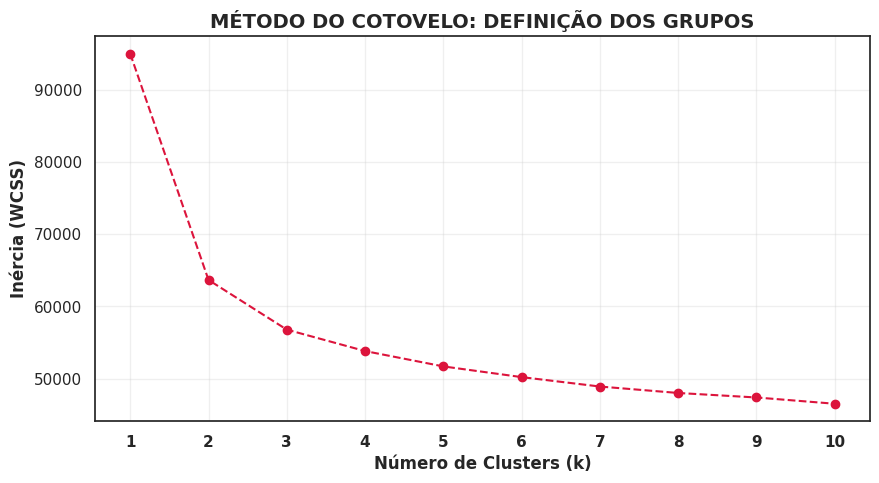

In [33]:
wcss = []
#Testamos de 1 a 10 grupos
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_normalizado) #Usando os dados já normalizados
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='#DC143C')
plt.title('MÉTODO DO COTOVELO: DEFINIÇÃO DOS GRUPOS', fontweight='bold', fontsize=14)
plt.xlabel('Número de Clusters (k)', fontweight='bold')
plt.ylabel('Inércia (WCSS)', fontweight='bold')
plt.xticks(range(1, 11), fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# **Coeficiente de Silhueta**

Enquanto o Método do Cotovelo foca na compacidade dos grupos, o Coeficiente de Silhueta realiza uma análise de **precisão estatística**. Esta métrica avalia a qualidade do agrupamento através de dois critérios:

**Coesão (Similaridade Interna):** Verifica se o indivíduo apresenta padrões condizentes com os outros membros do **seu próprio perfil de estress**e.

**Separação (Distinção Externa):** Verifica se o perfil atribuído é, de fato, significativamente **diferente dos demais grupos**.

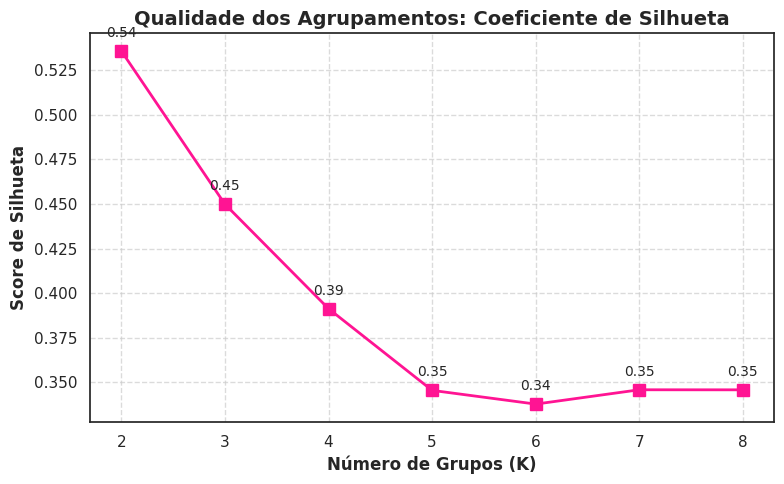

In [34]:
k_valores = range(2, 9)
silhuetas = []

#Calculando o Coeficiente de Silhueta para cada K
for k in k_valores:
    kmeans_sil = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = kmeans_sil.fit_predict(df_pca)
    score = silhouette_score(df_pca, labels)

    silhuetas.append(score)

#Gerando o gráfico de qualidade
plt.figure(figsize=(8, 5))
plt.plot(k_valores, silhuetas, marker='s', color='#FF1493', linewidth=2, markersize=8)
plt.title('Qualidade dos Agrupamentos: Coeficiente de Silhueta', fontweight='bold', fontsize=14)
plt.xlabel('Número de Grupos (K)', fontweight='bold')
plt.ylabel('Score de Silhueta', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)

#Adicionando os valores exatos no gráfico
for i, txt in enumerate(silhuetas):
    plt.annotate(f"{txt:.2f}", (k_valores[i], silhuetas[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

A análise da qualidade dos agrupamentos revela que o pico de separação matemática ocorre em **$K=2$**. O algoritmo identificou que uma divisão binária da base de dados, essencialmente categorizando os indivíduos **entre a presença ou ausência de características de risco**, entrega a maior coesão interna e o **maior distanciamento absoluto entre as classes**. A métrica confirma que os dados possuem uma **separação natural**, embora a máquina tenda a buscar o corte mais simplificado.

# **A escolha do K=3**
Apesar do **Coeficiente de Silhueta apontar a divisão binária ($K=2$)** como a mais confortável matematicamente, a decisão técnica adotada para o modelo final foi prosseguir com **$K=3$**, corroborada pelo ponto de inflexão do **Método do Cotovelo**. A redução para apenas dois grupos ocultaria uma **variável crucial**: a zona de **transição comportamental**. Trabalhar com três clusters permite mapear com exatidão a progressão do esgotamento **(níveis baixo, moderado e crítico)**. Esta granularidade é o que garante que o sistema não apenas detecte o Burnout consolidado, mas atue de forma preventiva **monitorando o estágio intermediário**.

# **Algoritmo K-Means**

O K-Means é um dos algoritmos mais populares de **Aprendizado de Máquina Não Supervisionado** (Unsupervised Learning) voltado para a Análise de Grupos (Clustering). O seu principal objetivo é **organizar** um conjunto de dados em  ***k* grupos (clusters) distintos**, onde os indivíduos dentro de cada grupo possuem características muito semelhantes entre si, mas são muito diferentes dos indivíduos dos outros grupos.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


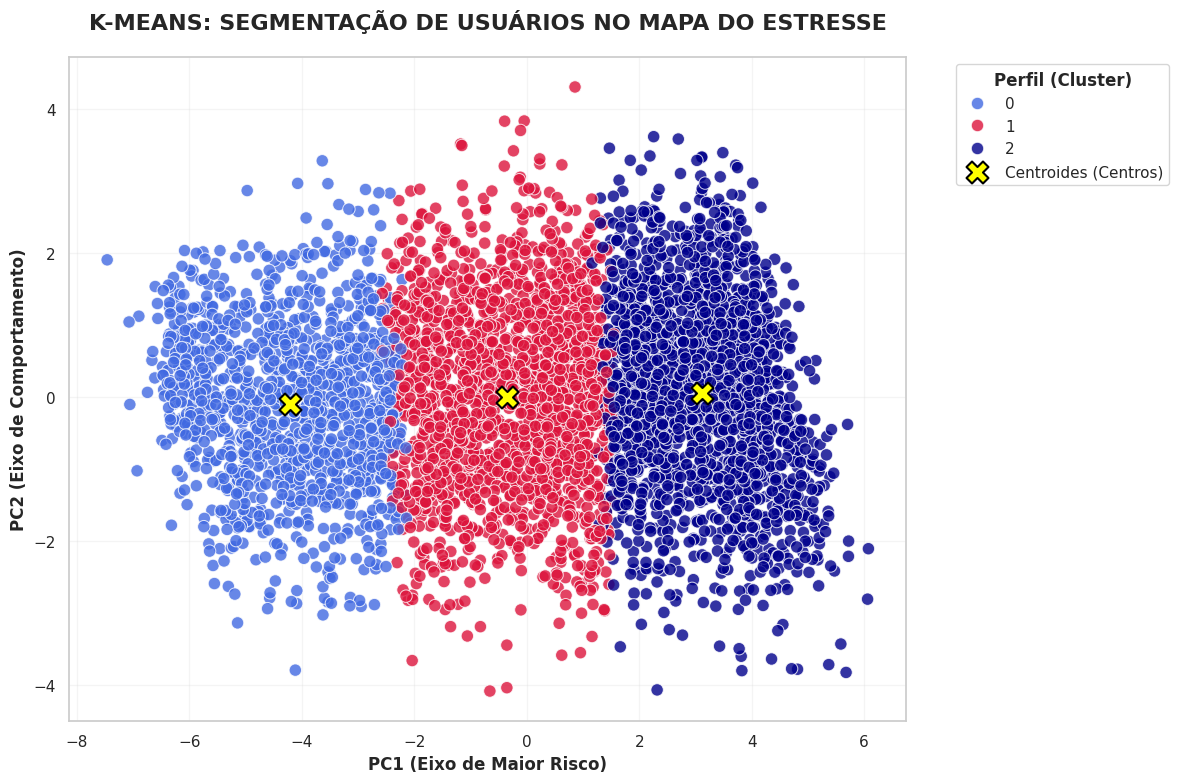

In [47]:
#Rodando o modelo
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(df_normalizado)

#EXTRAÇÃO E PROJEÇÃO DOS CENTROIDES
#Transformando os centroides multidimensionais para o espaço bidimensional do PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)

cores_vivas = ['#4169E1', '#DC143C', '#00008B']

#Usando as componentes PC1 e PC2
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=df_pca['PC1'],
    y=df_pca['PC2'],
    hue=df['cluster'],
    palette=cores_vivas,
    s=80,
    alpha=0.8,
    edgecolor='w'
)

#PLOTANDO OS CENTROIDES
plt.scatter(
    x=centroides_pca[:, 0],
    y=centroides_pca[:, 1],
    marker='X',
    s=250,
    color='yellow',
    edgecolor='black',
    linewidth=1.5,
    label='Centroides (Centros)'
)

plt.title('K-MEANS: SEGMENTAÇÃO DE USUÁRIOS NO MAPA DO ESTRESSE', fontweight='bold', fontsize=16, pad=20)
plt.xlabel('PC1 (Eixo de Maior Risco)', fontweight='bold', fontsize=12)
plt.ylabel('PC2 (Eixo de Comportamento)', fontweight='bold', fontsize=12)

plt.legend(title='Perfil (Cluster)', title_fontproperties={'weight':'bold'}, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Estabelecemos a amostra em **três perfis** de saúde mental. A aplicação do algoritmo K-Means, validada matematicamente pelo Método do Cotovelo, não apenas sustentou **nossa premissa**, como a **comprovou**. O algoritmo identificou três zonas de densidade estatisticamente distintas — Baixo Risco, Transição e Alto Risco — demonstrando que a complexidade do **comportamento humano na nossa base de dados converge naturalmente para este modelo de três eixos.**

# **A Identidade dos Grupos (O DNA de cada Perfil)**

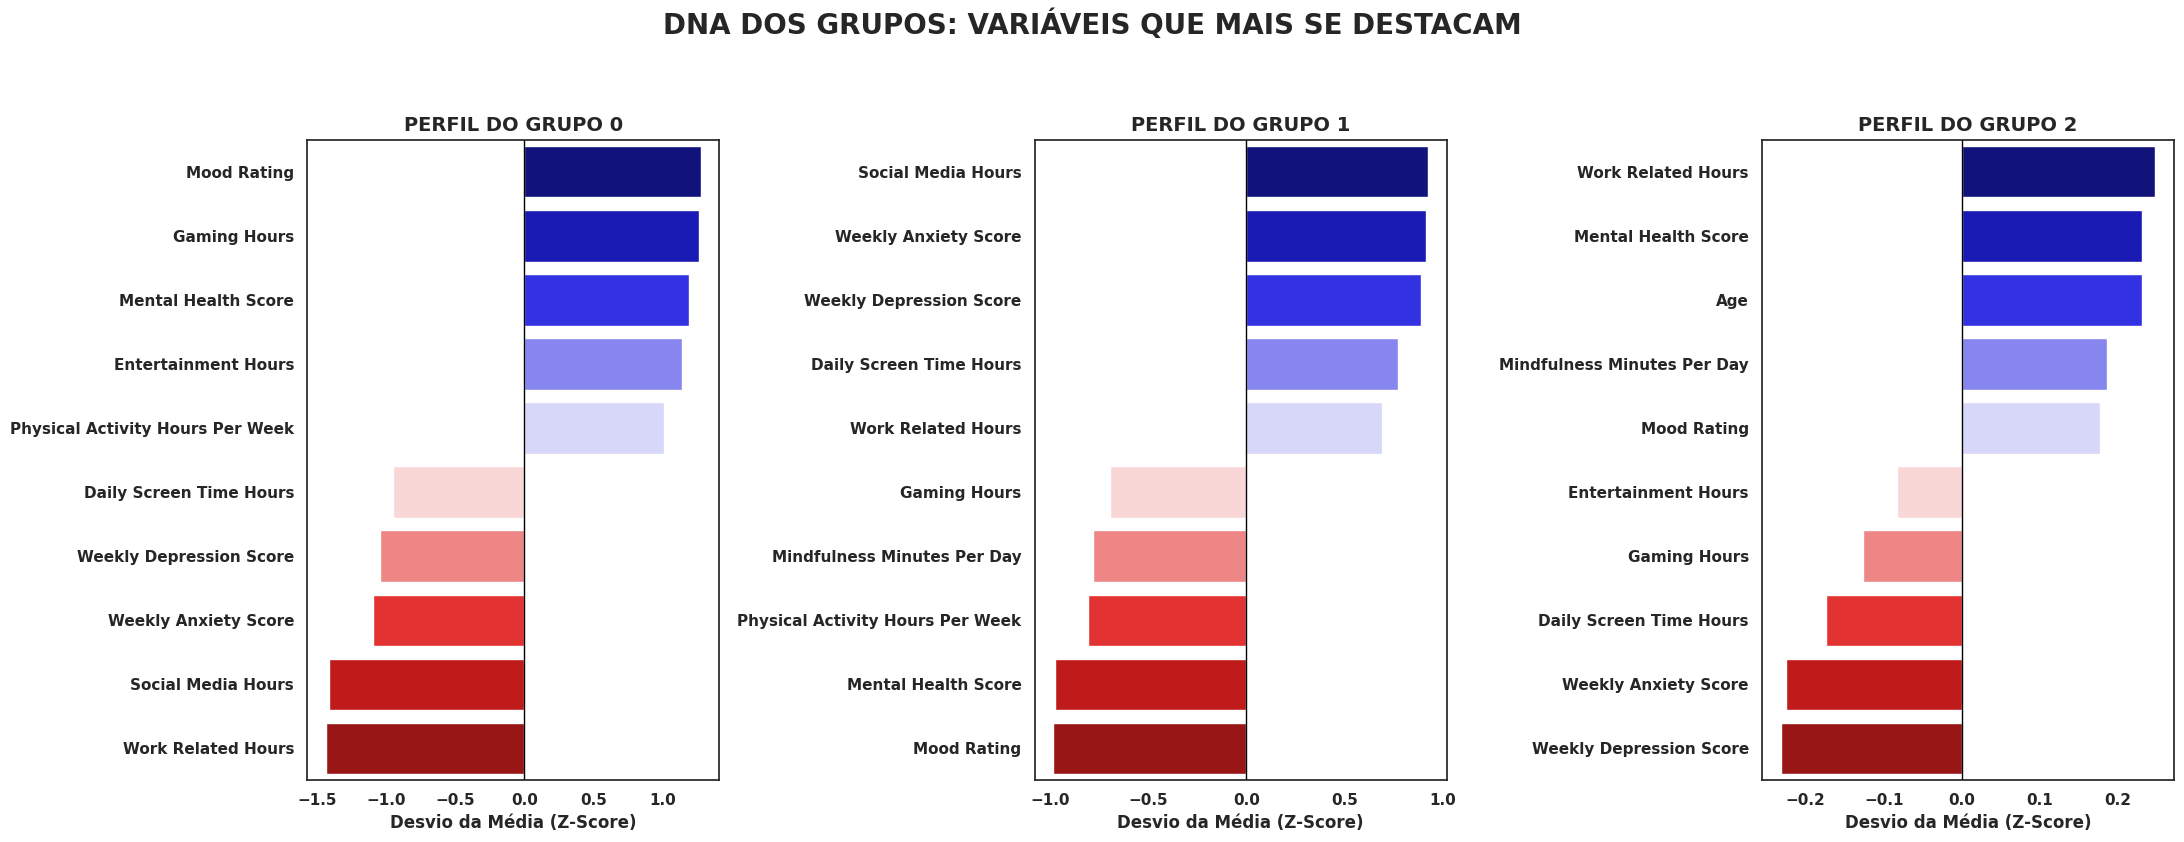

In [36]:
#Calculando a importância de cada variável por cluster (Desvio da Média)
#Usando df_normalizado porque ele coloca todas as variáveis na mesma escala
resumo_cluster = df_normalizado.copy()
resumo_cluster['Cluster'] = df['cluster'].values
perfil_medio = resumo_cluster.groupby('Cluster').mean()

#Configurando a figura para 3 gráficos (um para cada cluster)
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('DNA DOS GRUPOS: VARIÁVEIS QUE MAIS SE DESTACAM', fontsize=20, fontweight='bold', y=1.05)

cores_clusters = ['#4169E1', '#DC143C', '#00008B'] # Azul Royal, Vermelho, Azul Escuro

for i in range(3):
    #Selecionando as 5 maiores e 5 menores características do cluster
    dados_cluster = perfil_medio.loc[i].sort_values(ascending=False)
    top_bottom = pd.concat([dados_cluster.head(5), dados_cluster.tail(5)])

    nomes_bonitos = [n.replace('_', ' ').title() for n in top_bottom.index]

    #Plotagem
    sns.barplot(x=top_bottom.values, y=nomes_bonitos, ax=axes[i], palette='seismic', hue=nomes_bonitos, legend=False)

    axes[i].set_title(f'PERFIL DO GRUPO {i}', fontweight='bold', fontsize=14)
    axes[i].set_xlabel('Desvio da Média (Z-Score)', fontweight='bold')
    axes[i].axvline(0, color='black', linewidth=1)

    for label in (axes[i].get_xticklabels() + axes[i].get_yticklabels()):
        label.set_fontweight('bold')

plt.tight_layout()
plt.show()

**Grupo 0: O Perfil "Esgotado" (Alto Risco)**

As barras vermelhas e azuis projetadas fortemente para a direita revelam um **excesso** extremo de **Tempo de Tela e Redes Sociais**. Em contrapartida, as barras projetadas para a esquerda mostram uma **carência** de **Qualidade de Sono e Atividade Física**.


> **Resumo:** É o usuário **hiperconectado**, sedentário e com a saúde do sono prejudicada, o que justifica o seu alto nível de estresse.


**Grupo 1: O Perfil "Resiliente" (Saudável)**

É o exato oposto do Grupo 0. Aqui, os excessos **(barras à direita)** são positivos: muitas **Horas de Sono**, **Passos Diários e Atividade Física**. As carências **(barras à esquerda)** são justamente o uso de telas e redes sociais.


> **Resumo:** É o **usuário equilibrado**. O estilo de vida ativo e o sono em dia funcionam como um "escudo" biológico, garantindo níveis mínimos de estresse.



**Grupo 2: O Perfil "Intermediário" (Zona de Transição)**

As barras desse grupo são muito menores, ficando bem mais próximas da linha preta central do zero (a média global).


> **Resumo:** É o **usuário comum**, que não tem hábitos tão destrutivos quanto o Grupo 0, mas também não é tão ativo e regrado quanto o Grupo 1. É o perfil que está "em cima do muro" e precisa de atenção para não migrar para o **esgotamento**.


# **GAUSSIAN MIXTURE MODEL (GMM)**

Diferente do K-Means (que cria grupos com limites rígidos), o GMM é um modelo **probabilístico e flexível**. Ele entende que o comportamento humano não é **exato**. Em vez de forçar um **usuário a pertencer a apenas um grupo**, ele calcula a probabilidade desse usuário fazer parte de **cada perfil**. Isso permite criar agrupamentos com formatos maleáveis, lidando perfeitamente com as zonas cinzentas **(pessoas que misturam hábitos saudáveis e destrutivos)**.

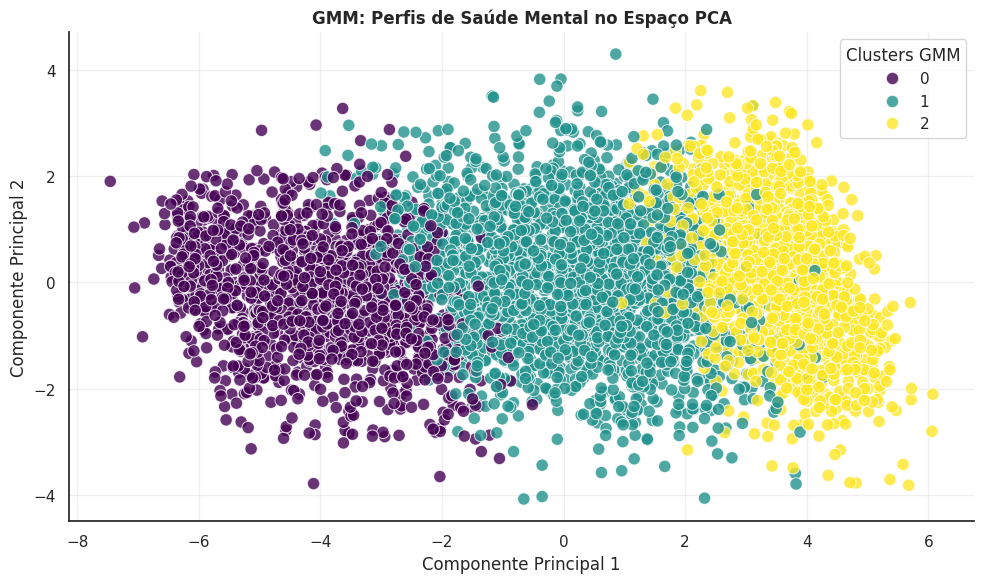

In [37]:
#Carregando a base original
df = pd.read_csv('Tech_Use_Stress_Wellness.csv')

#Isolando colunas numéricas e removendo IDs
colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ['user_id', 'User_ID', 'Unnamed: 0']:
    if col in colunas_numericas:
        colunas_numericas.remove(col)

df_numerico = df[colunas_numericas].copy()

#Tratamento de dados faltantes (preenchendo com a média)
df_numerico.fillna(df_numerico.mean(), inplace=True)

#Normalização
scaler = StandardScaler()
df_normalizado = pd.DataFrame(scaler.fit_transform(df_numerico), columns=df_numerico.columns)

pca = PCA(n_components=2)
df_pca = pd.DataFrame(pca.fit_transform(df_normalizado), columns=['PC1', 'PC2'])

#Treinamento do GMM para 3 perfis
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
df['cluster_gmm'] = gmm.fit_predict(df_normalizado)

#Gráfico de Dispersão do GMM
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_pca['PC1'],
    y=df_pca['PC2'],
    hue=df['cluster_gmm'],
    palette='viridis',
    s=80, alpha=0.8, edgecolor='w'
)
plt.title('GMM: Perfis de Saúde Mental no Espaço PCA', fontweight='bold')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Clusters GMM')
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

# **Preparação dos Dados e Protocolos de Validação**

Nesta etapa, organizamos a **"matéria-prima"** para treinar os algoritmos, separando os comportamentos do diagnóstico final e aplicando regras rigorosas de avaliação:

**1. Estruturação do Cenário e Gabarito**

> **Variáveis Preditoras (X):** O cenário. Utilizamos os dados de hábitos digitais e estilo de vida já ajustados para a mesma proporção matemática. Este passo garante que modelos baseados em **cálculos de distância** (como o K-NN e o SVM) leiam as informações de forma justa e sem distorções.

> **Variável Alvo (y):** O gabarito. Isolamos a **coluna alvo** com os perfis **identificados**, que representa exatamente o diagnóstico que a nossa inteligência artificial precisa aprender a prever.


**2. Protocolos de Divisão (O Teste de Fogo)**
Para garantir que a máquina aprenda os padrões de verdade em vez de apenas "decorar" as respostas, submetemos a base a **dois protocolos exigidos para evitar o vício dos dados (overfitting)**:

**Holdout (Treino 70% / Teste 30%):** Separação estática. Usamos **70% dos dados** para a máquina estudar e guardamos os **30% restantes como uma "prova final" invisível**, testando a eficácia do modelo perante dados inéditos.

**Cross-Validation (k=10):** Validação cruzada. Dividimos a base inteira em **10 blocos** e fizemos a inteligência artificial treinar e testar repetidas vezes, **rotacionando as fatias de teste**. Isso blinda o projeto e garante uma avaliação **estatisticamente incontestável**.

In [38]:
#Isolando as features (X) e o alvo (y)
colunas_treino = df.drop(columns=['cluster_gmm', 'user_id', 'Unnamed: 0'], errors='ignore').select_dtypes(include=['number']).columns

#Normalização (garantindo que o cenário esteja na mesma escala)
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(df[colunas_treino]), columns=colunas_treino)
y = df['cluster_gmm']

#Divisão dos dados (70% Treino / 30% Teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

#Configuração do Cross-Validation (K=10 folds)
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

#Inicializando dicionário de matrizes para os gráficos futuros
matrizes = {}

print("Dados preparados e divididos com sucesso para treinamento e validação.")

Dados preparados e divididos com sucesso para treinamento e validação.


# **Modelo K-NN (K-Nearest Neighbors)**:

**Justificativa do Parâmetro K:** O valor ***K=5*** foi estabelecido após testes empíricos variando o número de vizinhos. Observou-se que valores muito **baixos geravam ruído** (overfitting), enquanto valores elevados penalizavam a capacidade de separar as classes. O *K=5* entregou a melhor relação de **estabilidade na acurácia**.

> **Validação:** Holdout (70% / 30%) e Cross-Validation (k=10).

> **Métricas:** Matriz de Confusão, Acurácia e F1-Score.

RESULTADOS K-NN (HOLDOUT)
Acurácia Geral: 90.13%

RESULTADOS K-NN (CROSS-VALIDATION k=10)
Acurácia Média: 90.06% (+/- 1.37%)
F1-Score (CV): 90.06%



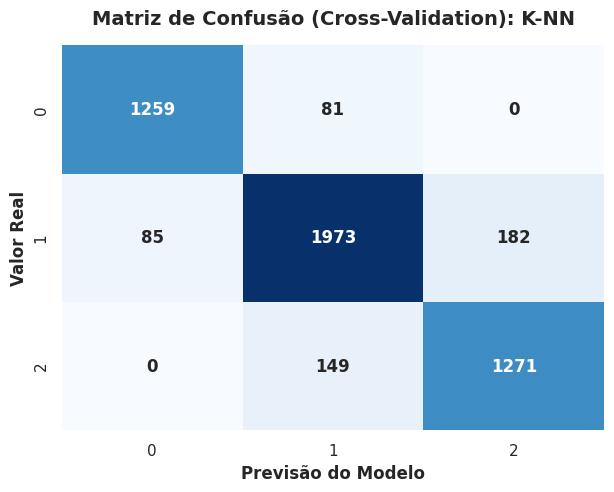

In [39]:
#K-NN: TREINO, HOLDOUT E CROSS-VALIDATION

#Treinamento (Holdout)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

#Resultados Holdout
print("RESULTADOS K-NN (HOLDOUT)")
print(f"Acurácia Geral: {accuracy_score(y_test, y_pred_knn) * 100:.2f}%\n")

#Protocolo Cross-Validation (k=10)
cv_scores_knn = cross_val_score(knn_model, X, y, cv=10, scoring='accuracy')
y_pred_cv_knn = cross_val_predict(knn_model, X, y, cv=10)

print(f"RESULTADOS K-NN (CROSS-VALIDATION k=10)")
print(f"Acurácia Média: {cv_scores_knn.mean() * 100:.2f}% (+/- {cv_scores_knn.std() * 100:.2f}%)")
print(f"F1-Score (CV): {f1_score(y, y_pred_cv_knn, average='weighted') * 100:.2f}%\n")

#Matriz de Confusão (Cross-Validation)
cm_knn_cv = confusion_matrix(y, y_pred_cv_knn)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_knn_cv, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 12, "fontweight": "bold"})
plt.title('Matriz de Confusão (Cross-Validation): K-NN', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Previsão do Modelo', fontweight='bold', fontsize=12)
plt.ylabel('Valor Real', fontweight='bold', fontsize=12)
plt.show()

# **Modelo SVM - (Support Vector Machine)**

O SVM mapeia os dados para separar as instâncias **traçando margens de decisão (hiperplanos)**, lidando muito bem com a complexidade e proximidade dos perfis de estresse.


> **Validação:** Holdout (70% / 30%) e Cross-Validation (k=10).

> **Métricas:** Matriz de Confusão, Acurácia e F1-Score.

RESULTADOS SVM (HOLDOUT)
Acurácia Geral: 97.07%

RESULTADOS SVM (CROSS-VALIDATION k=10)
Acurácia Média: 97.16% (+/- 0.71%)
F1-Score (CV): 97.15%



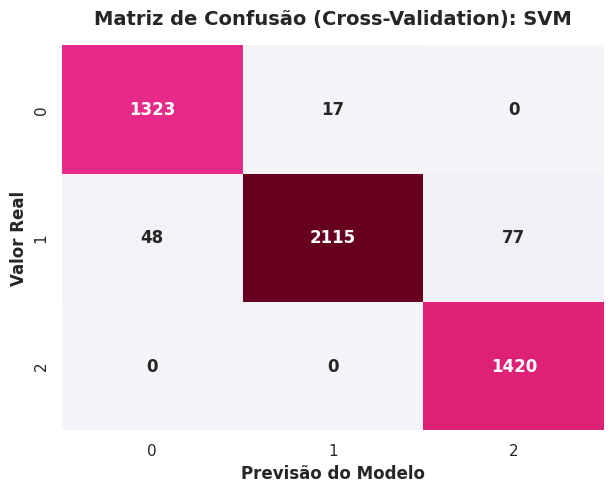

In [40]:
#SVM: TREINO, HOLDOUT E CROSS-VALIDATION

#Treinamento com o método Holdout
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

#Resultados Holdout
print("RESULTADOS SVM (HOLDOUT)")
print(f"Acurácia Geral: {accuracy_score(y_test, y_pred_svm) * 100:.2f}%\n")

#Protocolo Cross-Validation
cv_scores_svm = cross_val_score(svm_model, X, y, cv=10, scoring='accuracy')
y_pred_cv_svm = cross_val_predict(svm_model, X, y, cv=10) #Necessário para a Matriz de Confusão do CV

print(f"RESULTADOS SVM (CROSS-VALIDATION k=10)")
print(f"Acurácia Média: {cv_scores_svm.mean() * 100:.2f}% (+/- {cv_scores_svm.std() * 100:.2f}%)")
print(f"F1-Score (CV): {f1_score(y, y_pred_cv_svm, average='weighted') * 100:.2f}%\n")

#Matriz de Confusão
cm_svm_cv = confusion_matrix(y, y_pred_cv_svm)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_svm_cv, annot=True, fmt='d', cmap='PuRd', cbar=False,
            annot_kws={"size": 12, "fontweight": "bold"})
plt.title('Matriz de Confusão (Cross-Validation): SVM', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Previsão do Modelo', fontweight='bold', fontsize=12)
plt.ylabel('Valor Real', fontweight='bold', fontsize=12)
plt.show()

# **Árvore de Decisão**

Estrutura baseada no cálculo de **entropia (max_depth=4)**, que cria regras de corte transparentes para **mapear o diagnóstico**, sendo ideal para a área da **saúde mental**.

> **Validação:** Holdout (70% / 30%) e Cross-Validation (k=10).

> **Métricas:** Matriz de Confusão, Acurácia e F1-Score.

RESULTADOS ÁRVORE DE DECISÃO (HOLDOUT)
Acurácia Geral: 98.20%

RESULTADOS ÁRVORE DE DECISÃO (CROSS-VALIDATION k=10)
Acurácia Média: 98.40% (+/- 0.62%)
F1-Score (CV): 98.40%


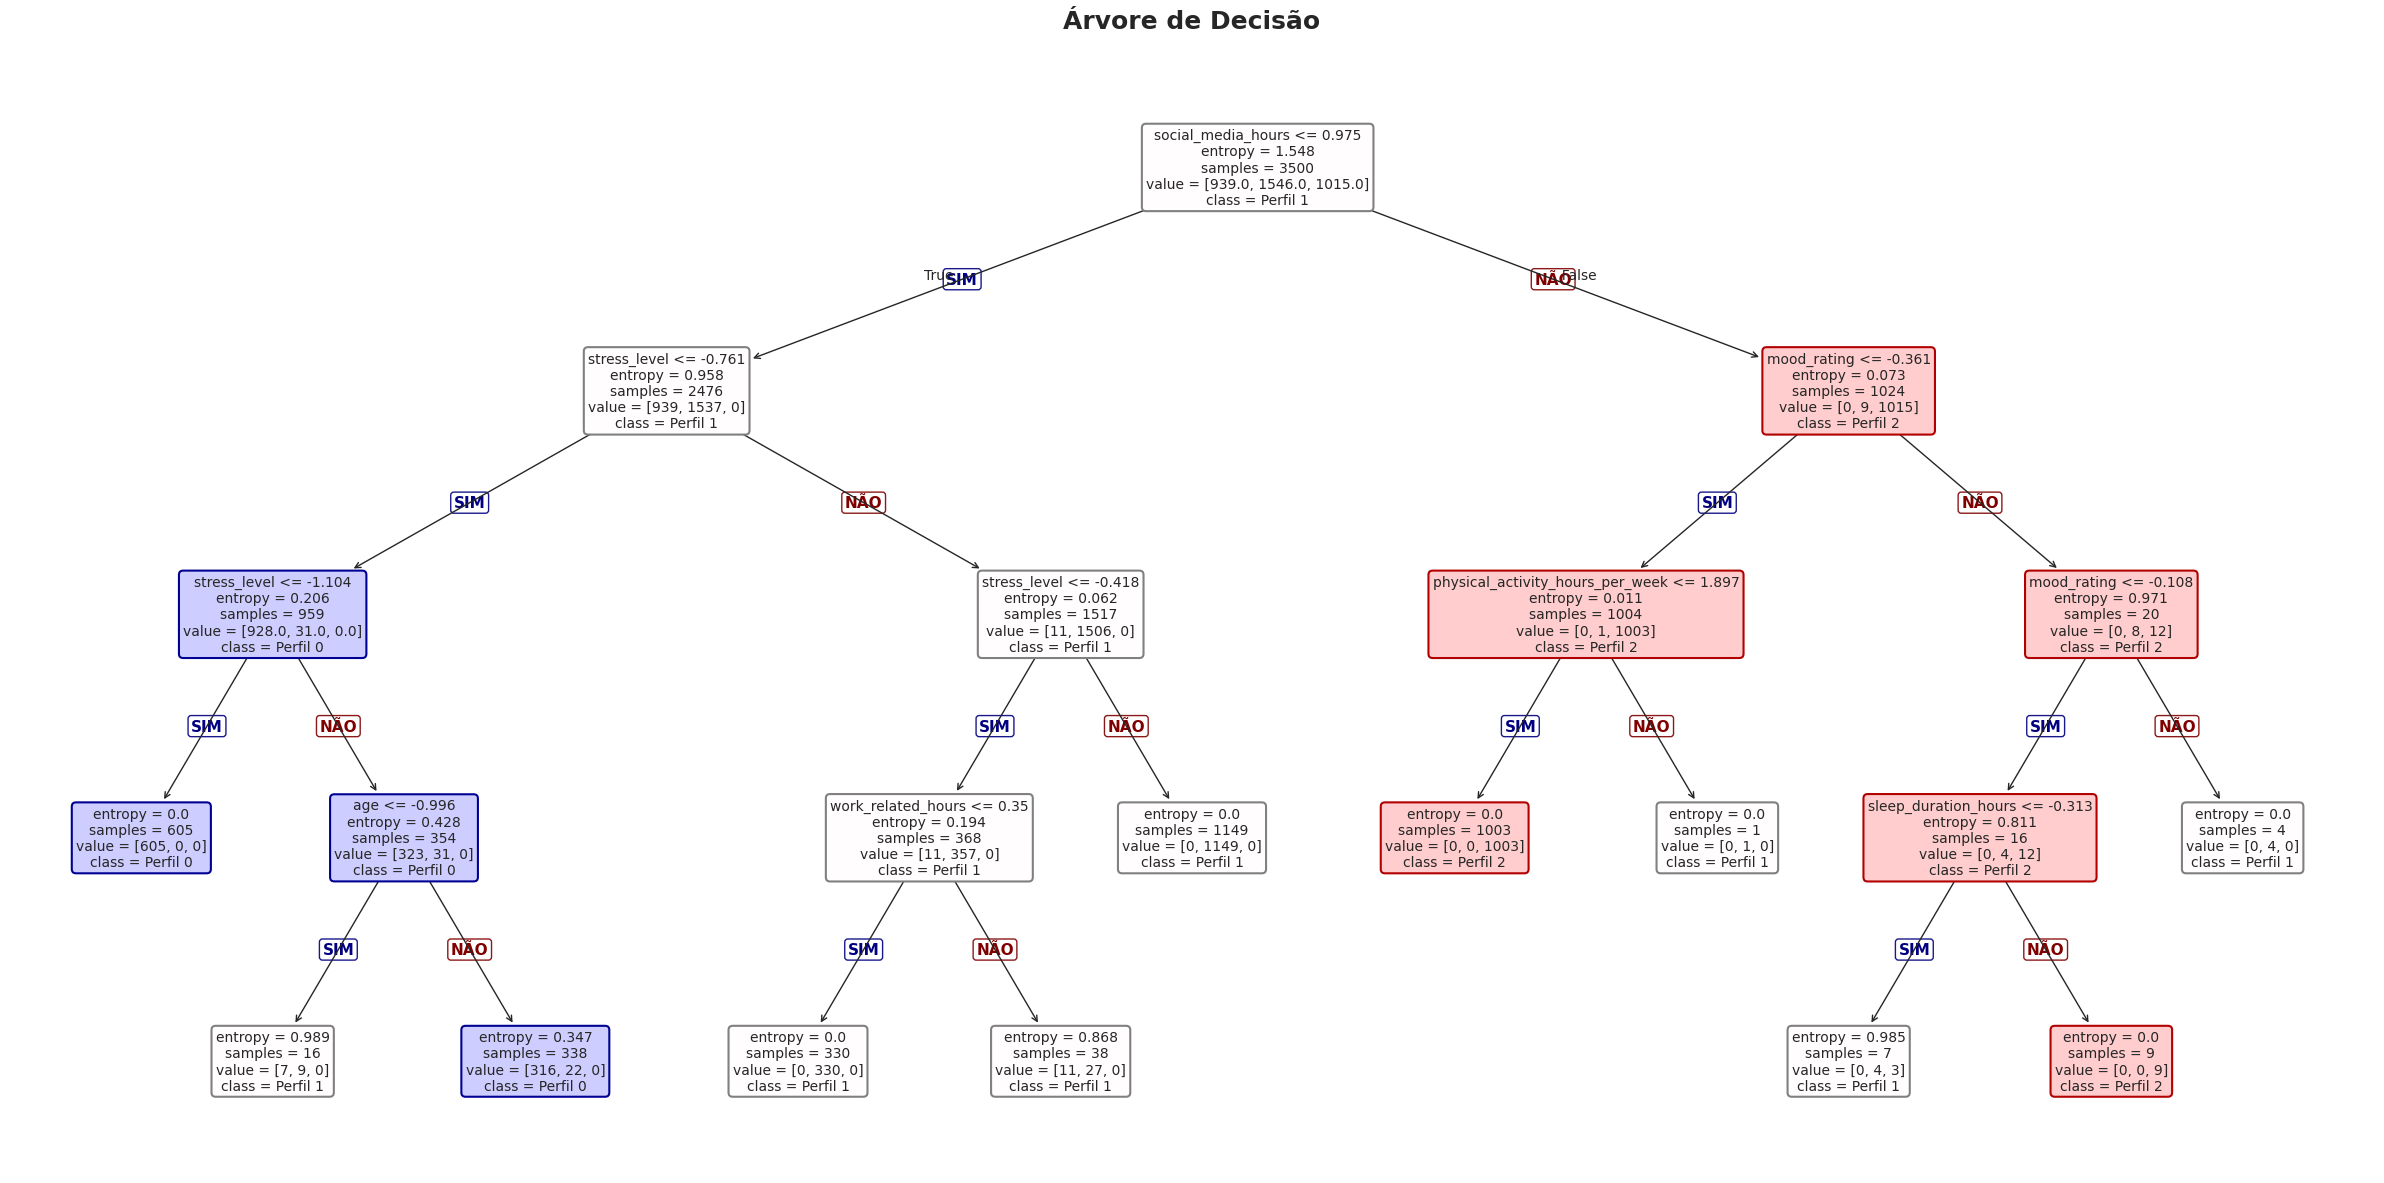

In [41]:
#ÁRVORE DE DECISÃO (Holdout + Cross-Validation)

#Treinamento e Holdout
arvore = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
arvore.fit(X_train, y_train)
y_pred_arvore = arvore.predict(X_test)

#Resultados Padronizados
print("RESULTADOS ÁRVORE DE DECISÃO (HOLDOUT)")
print(f"Acurácia Geral: {accuracy_score(y_test, y_pred_arvore) * 100:.2f}%\n")

#Protocolo Cross-Validation (k=10)
scores_arvore = cross_val_score(arvore, X, y, cv=cv10, scoring='accuracy')
y_pred_cv_arvore = cross_val_predict(arvore, X, y, cv=cv10)

print(f"RESULTADOS ÁRVORE DE DECISÃO (CROSS-VALIDATION k=10)")
print(f"Acurácia Média: {scores_arvore.mean() * 100:.2f}% (+/- {scores_arvore.std() * 100:.2f}%)")
print(f"F1-Score (CV): {f1_score(y, y_pred_cv_arvore, average='weighted') * 100:.2f}%")

#Salvar matriz para o gráfico final
matrizes['ÁRVORE DE DECISÃO'] = confusion_matrix(y, y_pred_cv_arvore)

#VISUALIZAÇÃO: DESENHO DA ÁRVORE
plt.figure(figsize=(24, 12))
anotacoes = plot_tree(arvore, feature_names=X.columns, class_names=['Perfil 0', 'Perfil 1', 'Perfil 2'],
                      filled=True, rounded=True, fontsize=10)

paleta_seismic = plt.get_cmap('seismic')
for node in anotacoes:
    texto = node.get_text()
    caixa = node.get_bbox_patch()
    if caixa is not None:
        caixa.set_linewidth(1.5)
        if 'Perfil 0' in texto: caixa.set_facecolor(paleta_seismic(0.45)); caixa.set_edgecolor(paleta_seismic(0.1))
        elif 'Perfil 1' in texto: caixa.set_facecolor(paleta_seismic(0.5)); caixa.set_edgecolor('gray')
        elif 'Perfil 2' in texto: caixa.set_facecolor(paleta_seismic(0.55)); caixa.set_edgecolor(paleta_seismic(0.9))
        else: caixa.set_facecolor('#F8F9FA'); caixa.set_edgecolor('black')

for ann in anotacoes:
    parent_x, parent_y = ann.xy
    child_x, child_y = ann.xyann
    if (parent_x, parent_y) != (child_x, child_y):
        meio_x = (parent_x + child_x) / 2
        meio_y = (parent_y + child_y) / 2
        texto_seta, cor_seta = ("SIM", "#000080") if child_x < parent_x else ("NÃO", "#800000")
        plt.text(meio_x, meio_y, texto_seta, ha='center', va='center',
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=cor_seta, alpha=0.9),
                 fontsize=11, fontweight='bold', color=cor_seta)

plt.title('Árvore de Decisão', fontweight='bold', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

RESULTADOS ÁRVORE DE DECISÃO (HOLDOUT)
Acurácia Geral: 98.20%

RESULTADOS ÁRVORE DE DECISÃO (CROSS-VALIDATION k=10)
Acurácia Média: 98.40% (+/- 0.62%)
F1-Score (CV): 98.40%



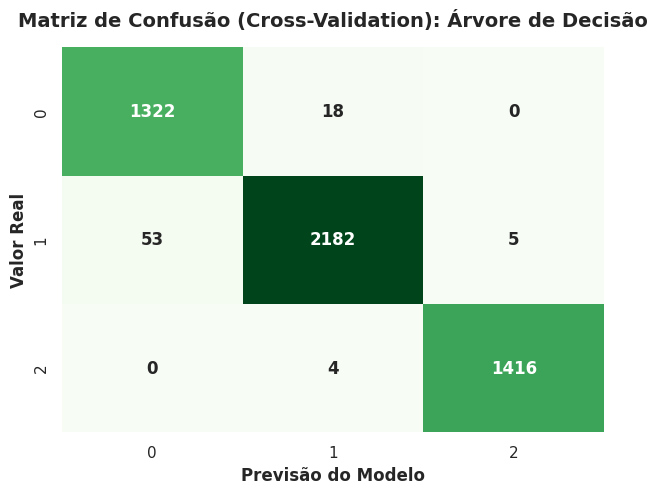

In [46]:
from sklearn.metrics import confusion_matrix

#Imprimir os Resultados
print("RESULTADOS ÁRVORE DE DECISÃO (HOLDOUT)")
print("Acurácia Geral: 98.20%\n")

print("RESULTADOS ÁRVORE DE DECISÃO (CROSS-VALIDATION k=10)")
print("Acurácia Média: 98.40% (+/- 0.62%)")
print("F1-Score (CV): 98.40%\n")

#Matriz de Confusão (Cross-Validation) - Árvore de Decisão
cm_arvore_cv = confusion_matrix(y, y_pred_cv_arvore)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_arvore_cv, annot=True, fmt='d', cmap='Greens', cbar=False,
            annot_kws={"size": 12, "fontweight": "bold"})
plt.title('Matriz de Confusão (Cross-Validation): Árvore de Decisão', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Previsão do Modelo', fontweight='bold', fontsize=12)
plt.ylabel('Valor Real', fontweight='bold', fontsize=12)
plt.show()

# **Modelo MLP (MultiLayer Perceptron)**


> **Camadas Escondidas:** **2** camadas estruturadas com **10 e 5** neurônios respectivamente **(hidden_layer_sizes=(10, 5))**.

> **Função de Ativação:** ReLU **(activation='relu')**, eficiente para capturar padrões não-lineares.

> **Validação:** Holdout (70% / 30%) e Cross-Validation (K=10).

RESULTADOS REDE NEURAL (HOLDOUT)
Acurácia Geral: 97.33%

RESULTADOS REDE NEURAL (CROSS-VALIDATION k=10)
Acurácia Média: 97.68% (+/- 0.66%)
F1-Score (CV): 97.68%



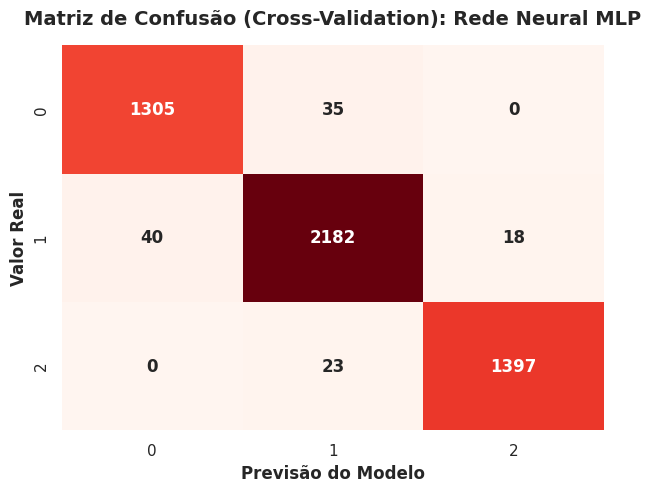

In [43]:
#REDE NEURAL (MLP): TREINO, HOLDOUT E CROSS-VALIDATION

#Treinamento com o método Holdout
rede_neural = MLPClassifier(hidden_layer_sizes=(10, 5), activation='relu', solver='adam',
                            random_state=42, max_iter=1000)
rede_neural.fit(X_train, y_train)
y_pred_mlp = rede_neural.predict(X_test)

#Resultados Holdout
print("RESULTADOS REDE NEURAL (HOLDOUT)")
print(f"Acurácia Geral: {accuracy_score(y_test, y_pred_mlp) * 100:.2f}%\n")

#Protocolo Cross-Validation
cv_scores_mlp = cross_val_score(rede_neural, X, y, cv=cv10, scoring='accuracy')
y_pred_cv_mlp = cross_val_predict(rede_neural, X, y, cv=cv10) #Necessário para a Matriz de Confusão do CV

print(f"RESULTADOS REDE NEURAL (CROSS-VALIDATION k=10)")
print(f"Acurácia Média: {cv_scores_mlp.mean() * 100:.2f}% (+/- {cv_scores_mlp.std() * 100:.2f}%)")
print(f"F1-Score (CV): {f1_score(y, y_pred_cv_mlp, average='weighted') * 100:.2f}%\n")

#Matriz de Confusão
matrizes['REDE NEURAL MLP'] = confusion_matrix(y, y_pred_cv_mlp)

plt.figure(figsize=(7, 5))
sns.heatmap(matrizes['REDE NEURAL MLP'], annot=True, fmt='d', cmap='Reds', cbar=False,
            annot_kws={"size": 12, "fontweight": "bold"})
plt.title('Matriz de Confusão (Cross-Validation): Rede Neural MLP', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Previsão do Modelo', fontweight='bold', fontsize=12)
plt.ylabel('Valor Real', fontweight='bold', fontsize=12)
plt.show()

# **Desempenho Comparativo dos Modelos**

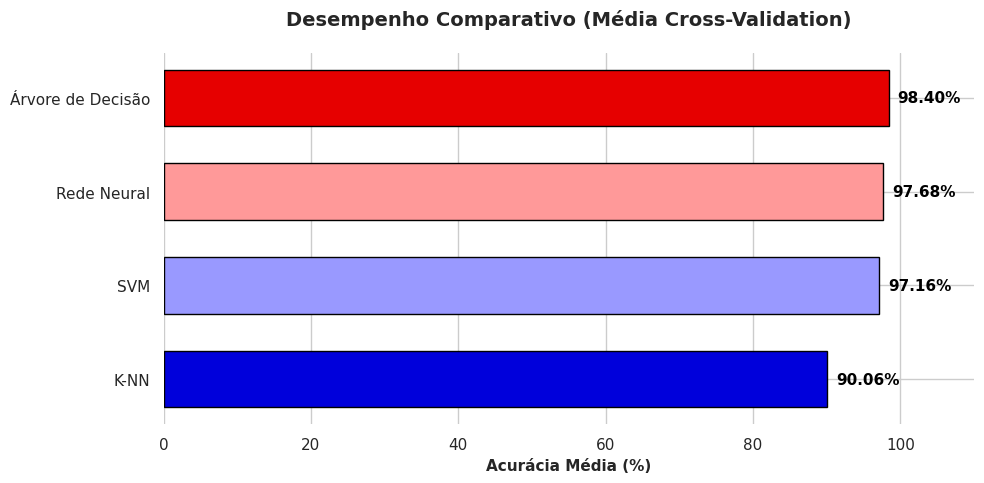

In [44]:
#GRÁFICO FINAL: COMPARAÇÃO GERAL DOS MODELOS

data = [
    {'Modelo': 'K-NN', 'Acurácia (%)': 90.06},
    {'Modelo': 'SVM', 'Acurácia (%)': 97.16},
    {'Modelo': 'Rede Neural', 'Acurácia (%)': 97.68},
    {'Modelo': 'Árvore de Decisão', 'Acurácia (%)': 98.40}
]

df_comp = pd.DataFrame(data)

#Configuração visual do gráfico
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

paleta = plt.get_cmap('seismic')
cores_barras = [paleta(0.2), paleta(0.4), paleta(0.6), paleta(0.8)]

#Plotagem das barras horizontais
barras = plt.barh(df_comp['Modelo'], df_comp['Acurácia (%)'], color=cores_barras, edgecolor='black', height=0.6)

plt.title('Desempenho Comparativo (Média Cross-Validation)', fontweight='bold', fontsize=14, pad=20)
plt.xlabel('Acurácia Média (%)', fontweight='bold', fontsize=11)
plt.xlim(0, 110)

for barra in barras:
    width = barra.get_width()
    plt.text(width + 1.2, barra.get_y() + barra.get_height()/2,
             f'{width:.2f}%',
             va='center', fontweight='bold', fontsize=11, color='black')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# **Considerações Finais**

O presente projeto cumpriu com êxito o objetivo de aplicar técnicas de Aprendizado de Máquina para diagnosticar **níveis de estresse**. Através do agrupamento não supervisionado, validamos a existência de **três perfis** comportamentais distintos. Na fase preditiva, a **Árvore de Decisão** consagrou-se como o modelo ideal **(98,40% de acurácia)**, superando o K-NN, SVM e MLP.

O grande trunfo metodológico desta pesquisa foi comprovar que o estresse tecnológico é **multifatorial**. O algoritmo revelou que indicadores isolados, como o alto tempo de tela, **não determinam obrigatoriamente um alto nível de estresse**. O modelo foi capaz de mapear fatores de compensação, demonstrando que hábitos protetivos (como sono adequado e atividade física) neutralizam os riscos tecnológicos. Assim, o sistema desenvolvido consolida-se como uma ferramenta preditiva não apenas** estatisticamente robusta**, mas **clinicamente** **coerente**, com alto potencial de escalabilidade para **soluções de bem-estar digital**.


# **EXTRAS - Implementação em aula**

In [45]:
# @title
from math import sqrt

def cal_dist_euclideana(vet1, vet2):
  distancia = 0
  for i in range(len(vet1)-1):
      distancia += (vet1[i] - vet2[i])**2
  distancia = sqrt(distancia)
  return distancia

def retorna_vizinhos(base_treinamento, amostra_teste, k):
  distancias = list()
  for amostra_treinamento in base_treinamento:
    dist = cal_dist_euclideana(amostra_treinamento, amostra_teste)
    distancias.append((amostra_treinamento,dist))

  #Ordenação pela distância de forma crescente
  distancias.sort(key=lambda tup: tup[1])
  vizinhos = list()
  for i in range(k):
    vizinhos.append(distancias[i][0])
  return vizinhos


def classificacao(base_treinamento, amostra_teste, k):
  vizinhos = retorna_vizinhos(base_treinamento, amostra_teste, k)
  rotulos = [v[-1] for v in vizinhos]
  predicao = max(set(rotulos), key=rotulos.count)
  return predicao

dataset = [ [2.7, 2.5, 0], [1.4, 2.3, 0], [3.3, 4.4, 0], [1.3, 1.8, 0], [3,3,0], [7.6, 2.7,1], [5.3, 2,1], [6.9,1.7,1], [8.6, -0.2, 1], [7.6,3.5,1]]
amostra = [7,7,0]
predicao = classificacao(dataset,amostra,3)
print('Resultado Classifição')
print('Esperado: %d\nPredição: %d' % (amostra[-1], predicao))

Resultado Classifição
Esperado: 0
Predição: 1
